# PEG1 (GSE111629) cohort

In [2]:
import os
import gc
import json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch_geometric.data import Data, Batch
from torch_geometric.nn import GATConv, GlobalAttention
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score

/opt/conda/envs/rapids-env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Define the functional map

In [2]:
FUNCTIONAL_MAP = {
    'TSS200': 0, 'TSS1500': 1, '1stExon': 2, 
    "5'UTR": 3, 'Body': 4, "3'UTR": 5, 'Other': 6
}

## Build the Chromosome topologies

In [3]:
def build_chromosome_topologies(manifest_df, common_probes, max_linear_dist_bp=1000):
    manifest = manifest_df[manifest_df['IlmnID'].isin(common_probes)].copy()
    manifest['CHR'] = manifest['CHR'].astype(str).str.replace('chr', '')
    manifest = manifest[manifest['CHR'].isin([str(i) for i in range(1, 23)])]
    manifest['MAPINFO'] = manifest['MAPINFO'].astype(int)
    
    chr_topologies = {}
    
    for c in range(1, 23):
        chr_str = str(c)
        sub = manifest[manifest['CHR'] == chr_str].sort_values(by='MAPINFO').reset_index(drop=True)
        probe_list = sub['IlmnID'].tolist()
        probe_to_idx = {p: i for i, p in enumerate(probe_list)}
        positions = sub['MAPINFO'].values
        n_nodes = len(probe_list)
        
        # A. Encode primary functional annotation
        func_labels = np.full(n_nodes, FUNCTIONAL_MAP['Other'], dtype=np.int64)
        for idx, row in sub.iterrows():
            grps = str(row.get('UCSC_RefGene_Group', '')).split(';')
            if grps and grps[0] in FUNCTIONAL_MAP:
                func_labels[idx] = FUNCTIONAL_MAP[grps[0]]
                
        # B. EXPLICIT SELF LOOPS (Fixes Empty Edge Crash & Mathematically sound for GAT)
        edges = [[i, i] for i in range(n_nodes)]
        
        # C. 1D Linear Adjacency Edges
        for i in range(n_nodes - 1):
            if 0 < (positions[i+1] - positions[i]) <= max_linear_dist_bp:
                edges.append([i, i + 1])
                edges.append([i + 1, i])
                
        # D. Shared Genic Annotation Edges
        gene_groups = {}
        for idx, row in sub.iterrows():
            genes = str(row.get('UCSC_RefGene_Name', '')).split(';')
            if genes and genes[0] not in ('', 'nan'):
                gene = genes[0]
                gene_groups.setdefault(gene, []).append(idx)
                
        for members in gene_groups.values():
            if 1 < len(members) <= 50:
                for i in range(len(members)):
                    for j in range(i + 1, len(members)):
                        edges.append([members[i], members[j]])
                        edges.append([members[j], members[i]])
                        
        # Because we initialized with self-loops, 'edges' is guaranteed non-empty
        edge_arr = np.unique(np.array(edges), axis=0).T
        edge_index = torch.tensor(edge_arr, dtype=torch.long)
            
        chr_topologies[c] = {
            'probes': probe_list,
            'edge_index': edge_index,
            'func_type': torch.tensor(func_labels, dtype=torch.long),
            'n_nodes': n_nodes
        }
        
    return chr_topologies

## PyTorch dataset and Trasposed Collator

In [4]:
LABEL_MAP = {'Control': 0.0, 'PD': 1.0}

class WholeBloodMethylationDataset(Dataset):
    def __init__(self, m_matrix_df, pheno_df, cell_cols, chr_topologies):
        self.sample_ids = pheno_df.index.tolist()
        
        # Explicit label encoding for BCEWithLogitsLoss
        labels = pheno_df['Sample_Group'].map(LABEL_MAP)
        if labels.isna().any():
            unknown_labels = sorted(pheno_df.loc[labels.isna(), 'Sample_Group'].astype(str).unique().tolist())
            raise ValueError(f"Unexpected Sample_Group values: {unknown_labels}")
        self.labels = labels.to_numpy(dtype=np.float32)
        
        self.cell_props = pheno_df[cell_cols].values.astype(np.float32)
        self.chr_topologies = chr_topologies
        
        self.chr_m_values = {}
        for c in range(1, 23):
            probes = chr_topologies[c]['probes']
            # Safe slice: guarantees no missing probes because df was pre-subsetted
            self.chr_m_values[c] = m_matrix_df.loc[self.sample_ids, probes].values.astype(np.float32)
            
    def __len__(self):
        return len(self.sample_ids)
        
    def __getitem__(self, idx):
        chr_graphs = []
        for c in range(1, 23):
            raw_x = torch.from_numpy(self.chr_m_values[c][idx]).unsqueeze(1)
            topo = self.chr_topologies[c]
            
            data = Data(
                x=raw_x,
                edge_index=topo['edge_index'],
                func_type=topo['func_type']
            )
            chr_graphs.append(data)
            
        u = torch.from_numpy(self.cell_props[idx])
        y = torch.tensor(self.labels[idx], dtype=torch.float32)
        return chr_graphs, u, y


def chromosome_collate_fn(batch):
    batched_chromosomes = []
    graphs_per_sample = [item[0] for item in batch]
    u_tensor = torch.stack([item[1] for item in batch])
    y_tensor = torch.stack([item[2] for item in batch])
    
    for chr_idx in range(22):
        chr_list = [graphs[chr_idx] for graphs in graphs_per_sample]
        batched_chromosomes.append(Batch.from_data_list(chr_list))
        
    return batched_chromosomes, u_tensor, y_tensor

## Chromosome-Parallel GAT Architecture

In [5]:
class ChromosomeParallelGAT(nn.Module):
    def __init__(self, num_node_classes=7, chr_embed_dim=16, cell_prop_dim=6):
        super(ChromosomeParallelGAT, self).__init__()
        
        self.func_embedding = nn.Embedding(num_embeddings=num_node_classes, embedding_dim=8)
        
        # add_self_loops=False because we explicitly defined them in the topology builder
        self.gat1 = GATConv(in_channels=9, out_channels=8, heads=2, concat=True, add_self_loops=False)
        self.gat2 = GATConv(in_channels=16, out_channels=chr_embed_dim, heads=1, concat=True, add_self_loops=False)
        
        self.gate_nn = nn.Sequential(
            nn.Linear(chr_embed_dim, 8),
            nn.ReLU(),
            nn.Linear(8, 1)
        )
        self.pool = GlobalAttention(gate_nn=self.gate_nn)
        
        fused_dim = (22 * chr_embed_dim) + cell_prop_dim
        self.classifier = nn.Sequential(
            nn.Linear(fused_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1)
        )
        
    def forward(self, batched_chrs, u_cells):
        chr_embeddings = []
        for c_idx in range(22):
            batch = batched_chrs[c_idx]
            
            emb_func = self.func_embedding(batch.func_type)
            node_feat = torch.cat([batch.x, emb_func], dim=1)
            
            h = torch.relu(self.gat1(node_feat, batch.edge_index))
            h = torch.relu(self.gat2(h, batch.edge_index))
            
            chr_emb = self.pool(h, batch.batch)
            chr_embeddings.append(chr_emb)
            
        genome_vector = torch.cat(chr_embeddings, dim=1)
        fused = torch.cat([genome_vector, u_cells], dim=1)
        return self.classifier(fused)

## 5-Fold CV

In [20]:
m_matrix_full = pd.read_feather("/workspace/data/GSE111629_data_test.feather")

This here fixes the m_matrix since the current parquet representation lacks all metadata/pheno columns including Sample_Name which causes failures further below...

In [ ]:
m_matrix_with_id = (
    m_matrix_full.copy()
    if 'Sample_Name' in m_matrix_full.columns
    else m_matrix_full.reset_index().rename(columns={m_matrix_full.index.name or 'index': 'Sample_Name'})
)

cols_to_keep = ['Sample_Name'] + [
    c for c in m_matrix_with_id.columns
    if c != 'Sample_Name' and c not in pheno_df.columns
]

m_matrix_full_reduced = m_matrix_with_id[cols_to_keep]
output_path = os.path.join("/workspace/data", "GSE111629_m_matrix_full_reduced.parquet")
m_matrix_full_reduced.to_parquet(output_path, index=False)
print(f"Saved to: {output_path}")

Saved to: /workspace/data/m_matrix_full_reduced.parquet


In [ ]:
m_matrix_full_reduced

In [33]:
m_matrix_full_reduced.head()

,cg16619049,cg23100540,cg18147296,cg13938959,cg12445832,cg23999112,cg11527153,cg27573606,cg04195702,cg08128007,...,cg19324023,cg09635994,cg19004771,cg20569369,cg26034629,cg25232725,cg05615487,cg22122449,cg08423507,cg19565306
Sample_Name,,,,,,,,,,,,,,,,,,,,,
GSM3035401,-0.391231,-1.572003,4.406984,0.778984,-0.906040,0.875549,4.271860,5.154080,3.761474,2.946690,...,3.354123,2.004086,1.929260,2.892161,4.913450,2.807751,4.782970,4.457486,5.246001,-6.148653
GSM3035402,-0.294673,-1.753355,3.439536,1.494787,-0.710042,0.808505,3.376785,5.194660,3.859485,3.366361,...,4.178481,1.938704,2.545114,2.160673,4.978455,2.912098,4.853534,4.736333,5.141731,-6.166355
GSM3035403,-1.009068,-1.895521,4.048525,0.860604,-0.790885,0.388188,4.297615,5.249513,3.691613,2.774799,...,3.367879,1.731055,1.931527,2.390308,5.219790,2.573055,4.933959,5.374524,5.142147,-6.167470
GSM3035404,-0.718404,-1.937458,3.281372,1.547149,-0.438353,1.122274,2.447532,5.334864,3.865556,4.230160,...,2.990683,2.210517,1.962918,2.375698,4.828473,3.111890,4.963863,3.586690,5.095090,-6.178808
GSM3035405,-0.817407,-1.902594,3.006591,1.674067,-0.705906,1.484803,3.157014,4.982922,4.555103,2.642256,...,3.262536,1.902270,1.696990,2.303311,5.145214,2.800162,4.069010,4.884013,5.142816,-6.166770


In [7]:

pheno_path = "/workspace/data/GSE111629_pheno_data.parquet"
m_matrix_path = "/workspace/data/GSE111629_m_matrix_full_reduced.parquet"
manifest_path = "/workspace/data/infinium450k_manifest.parquet"

LABEL_MAP = {'Control': 0, 'PD': 1}

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Executing GAT Pipeline on: {device}")

pheno_df = pd.read_parquet(pheno_path)
if pheno_df.index.name != "Sample_Name":
    pheno_df = pheno_df.set_index("Sample_Name")
    
cell_cols = ['CD8T', 'CD4T', 'NK', 'Bcell', 'Mono', 'Gran']
m_matrix_df = pd.read_parquet(m_matrix_path)
manifest_df = pd.read_parquet(manifest_path) 

m_matrix_df.set_index("Sample_Name", inplace=True)

# Strict validation to prevent index mismatch
common_probes = list(set(m_matrix_df.columns).intersection(set(manifest_df['IlmnID'])))
m_matrix_df = m_matrix_df[common_probes] # Discard unused columns to save RAM early
print(f"Total overlapping autosome probes: {len(common_probes):,}")

print("Building chromosome 1D adjacency and genic graphs...")
chr_topologies = build_chromosome_topologies(manifest_df, common_probes)

y = pheno_df['Sample_Group'].map(LABEL_MAP)
if y.isna().any():
    unknown_labels = sorted(pheno_df.loc[y.isna(), 'Sample_Group'].astype(str).unique().tolist())
    raise ValueError(f"Unexpected Sample_Group values: {unknown_labels}")
y = y.to_numpy(dtype=np.int64)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

roc_aucs, pr_aucs = [], []
batch_size = 16  
epochs = 40
lr = 2e-4

for fold, (train_idx, test_idx) in enumerate(skf.split(pheno_df, y)):
    print(f"\n--- Fold {fold + 1} ---")
    train_pheno = pheno_df.iloc[train_idx]
    test_pheno = pheno_df.iloc[test_idx]
    
    train_ds = WholeBloodMethylationDataset(m_matrix_df, train_pheno, cell_cols, chr_topologies)
    test_ds = WholeBloodMethylationDataset(m_matrix_df, test_pheno, cell_cols, chr_topologies)
    
    train_loader = DataLoader(train_ds, 
                              batch_size=batch_size, 
                              shuffle=True, 
                              collate_fn=chromosome_collate_fn,
                              num_workers=4,
                              pin_memory=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, collate_fn=chromosome_collate_fn)
    
    model = ChromosomeParallelGAT().to(device)
    
    # Explicit dtype declaration for pos_weight
    train_labels = train_pheno['Sample_Group'].map(LABEL_MAP)
    if train_labels.isna().any():
        unknown_labels = sorted(train_pheno.loc[train_labels.isna(), 'Sample_Group'].astype(str).unique().tolist())
        raise ValueError(f"Unexpected Sample_Group values in training fold: {unknown_labels}")
    train_labels = train_labels.to_numpy(dtype=np.float32)
    positives = float((train_labels == 1.0).sum())
    negatives = float((train_labels == 0.0).sum())
    if positives == 0:
        raise ValueError("Training fold has no positive samples, cannot compute pos_weight")
    pos_weight = torch.tensor([negatives / positives], device=device, dtype=torch.float32)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-3)
    
    # Training
    model.train()
    for epoch in range(epochs):
        total_loss = 0.0
        for batched_chrs, u_cells, batch_y in train_loader:
            
            # Asynchronous memory transfer
            batched_chrs = [c.to(device, non_blocking=True) for c in batched_chrs]
            u_cells = u_cells.to(device, non_blocking=True)
            batch_y = batch_y.to(device, non_blocking=True)
            
            optimizer.zero_grad()
            logits = model(batched_chrs, u_cells).squeeze(1)
            loss = criterion(logits, batch_y)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            
            # VRAM Fragmentation Protection
            del batched_chrs, u_cells, batch_y, logits, loss
            
    # Evaluation
    model.eval()
    preds, truths = [], []
    with torch.no_grad():
        for batched_chrs, u_cells, batch_y in test_loader:
            batched_chrs = [c.to(device, non_blocking=True) for c in batched_chrs]
            u_cells = u_cells.to(device, non_blocking=True)
            
            logits = model(batched_chrs, u_cells).squeeze(1)
            probs = torch.sigmoid(logits).cpu().numpy()
            
            preds.extend(probs)
            truths.extend(batch_y.numpy())
            
            del batched_chrs, u_cells, logits
            
    fold_roc = roc_auc_score(truths, preds)
    fold_pr = average_precision_score(truths, preds)
    roc_aucs.append(fold_roc)
    pr_aucs.append(fold_pr)
    print(f"Fold {fold + 1} | ROC AUC: {fold_roc:.4f} | PR AUC: {fold_pr:.4f}")

    # Save the model weights for downstream biological extraction
    torch.save(model.state_dict(), f"/workspace/results/gat_fold_{fold + 1}.pt")

    del model, optimizer, train_ds, test_ds
    torch.cuda.empty_cache()
    gc.collect()
    
print("\n" + "=" * 40)
print(f"Mean GAT ROC AUC: {np.mean(roc_aucs):.4f} ± {np.std(roc_aucs):.4f}")
print(f"Mean GAT PR AUC:  {np.mean(pr_aucs):.4f} ± {np.std(pr_aucs):.4f}")

Executing GAT Pipeline on: cuda
Total overlapping autosome probes: 421,114
Building chromosome 1D adjacency and genic graphs...

--- Fold 1 ---


/tmp/ipykernel_18700/2041644710.py:16: UserWarning: 'nn.glob.GlobalAttention' is deprecated, use 'nn.aggr.AttentionalAggregation' instead
  self.pool = GlobalAttention(gate_nn=self.gate_nn)


Fold 1 | ROC AUC: 0.6883 | PR AUC: 0.7273

--- Fold 2 ---


/tmp/ipykernel_18700/2041644710.py:16: UserWarning: 'nn.glob.GlobalAttention' is deprecated, use 'nn.aggr.AttentionalAggregation' instead
  self.pool = GlobalAttention(gate_nn=self.gate_nn)


Fold 2 | ROC AUC: 0.6839 | PR AUC: 0.7422

--- Fold 3 ---


...

Fold 3 | ROC AUC: 0.6846 | PR AUC: 0.7190

--- Fold 4 ---


/tmp/ipykernel_18700/2041644710.py:16: UserWarning: 'nn.glob.GlobalAttention' is deprecated, use 'nn.aggr.AttentionalAggregation' instead
  self.pool = GlobalAttention(gate_nn=self.gate_nn)


Fold 4 | ROC AUC: 0.6646 | PR AUC: 0.6952

--- Fold 5 ---


/tmp/ipykernel_18700/2041644710.py:16: UserWarning: 'nn.glob.GlobalAttention' is deprecated, use 'nn.aggr.AttentionalAggregation' instead
  self.pool = GlobalAttention(gate_nn=self.gate_nn)


Fold 5 | ROC AUC: 0.7167 | PR AUC: 0.7542

Mean GAT ROC AUC: 0.6876 ± 0.0167
Mean GAT PR AUC:  0.7276 ± 0.0202


In [12]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from torch_geometric.nn import GATConv, GlobalAttention
from torch_geometric.utils import softmax
from torch_geometric.data import Batch, Data

# =====================================================================
# 1. THE EXPLAINER ARCHITECTURE
# =====================================================================
# This is identical to your training architecture, but the forward pass 
# is modified to explicitly return the biological attention weights.
class GATExplainer(nn.Module):
    def __init__(self, num_node_classes=7, chr_embed_dim=16, cell_prop_dim=6):
        super(GATExplainer, self).__init__()
        self.func_embedding = nn.Embedding(num_embeddings=num_node_classes, embedding_dim=8)
        self.gat1 = GATConv(in_channels=9, out_channels=8, heads=2, concat=True, add_self_loops=False)
        self.gat2 = GATConv(in_channels=16, out_channels=chr_embed_dim, heads=1, concat=True, add_self_loops=False)
        
        self.gate_nn = nn.Sequential(
            nn.Linear(chr_embed_dim, 8),
            nn.ReLU(),
            nn.Linear(8, 1)
        )
        self.pool = GlobalAttention(gate_nn=self.gate_nn)
        
        fused_dim = (22 * chr_embed_dim) + cell_prop_dim
        self.classifier = nn.Sequential(
            nn.Linear(fused_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1)
        )

    def forward(self, batched_chrs, u_cells):
        genome_attention = {}
        
        for c_idx in range(22):
            batch = batched_chrs[c_idx]
            
            # Forward pass through GAT layers
            emb_func = self.func_embedding(batch.func_type)
            node_feat = torch.cat([batch.x, emb_func], dim=1)
            h = torch.relu(self.gat1(node_feat, batch.edge_index))
            h = torch.relu(self.gat2(h, batch.edge_index))
            
            # --- EXTRACT BIOLOGICAL IMPORTANCE ---
            # Calculate the raw importance score for every single CpG site
            raw_gate_scores = self.gate_nn(h).view(-1)
            # Normalize scores so they sum to 1.0 across the chromosome
            cpg_attention = softmax(raw_gate_scores, batch.batch)
            
            # Store the attention weights for this chromosome
            # Shape: [num_nodes_in_batch]
            genome_attention[c_idx + 1] = cpg_attention.detach().cpu().numpy()
            
        return genome_attention

# =====================================================================
# 2. EXTRACTION LOGIC
# =====================================================================
def extract_biological_drivers(model_path, m_matrix_df, pheno_df, chr_topologies, cell_cols):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Extracting on: {device}")
    
    # 1. Initialize and Load Weights
    model = GATExplainer().to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()
    
    # 2. Isolate Parkinson's Patients (We want to see what drives the PD signature)
    pd_samples = pheno_df[pheno_df['Sample_Group'] == 'PD'].index.tolist()
    print(f"Extracting drivers across {len(pd_samples)} PD patients...")
    
    # 3. Process Patients (Batch size 1 for clean extraction)
    # We will accumulate the attention weights to find the consensus drivers
    consensus_attention = {c: np.zeros(chr_topologies[c]['n_nodes']) for c in range(1, 23)}
    
    for sample in pd_samples:
        chr_graphs = []
        for c in range(1, 23):
            probes = chr_topologies[c]['probes']
            raw_x = torch.from_numpy(m_matrix_df.loc[sample, probes].values.astype(np.float32)).unsqueeze(1)
            data = Data(x=raw_x, edge_index=chr_topologies[c]['edge_index'], func_type=chr_topologies[c]['func_type'])
            chr_graphs.append(data)
            
        # Convert to PyG Batch format (batch size 1)
        batched_chrs = [Batch.from_data_list([g]).to(device) for g in chr_graphs]
        u = torch.tensor(pheno_df.loc[sample, cell_cols].values.astype(np.float32)).unsqueeze(0).to(device)
        
        # 4. Extract Attention
        with torch.no_grad():
            attention_dict = model(batched_chrs, u)
            
        for c in range(1, 23):
            consensus_attention[c] += attention_dict[c]

    # 5. Average the attention across all PD patients
    for c in range(1, 23):
        consensus_attention[c] /= len(pd_samples)
        
    return consensus_attention

# =====================================================================
# 3. MAP TO BIOLOGY & EXPORT
# =====================================================================
def map_and_export_drivers(consensus_attention, chr_topologies, manifest_df, export_path="pd_epigenetic_drivers.csv"):
    records = []
    
    for c in range(1, 23):
        probes = chr_topologies[c]['probes']
        weights = consensus_attention[c]
        
        for idx, probe in enumerate(probes):
            records.append({
                'IlmnID': probe,
                'Chromosome': c,
                'Attention_Score': weights[idx]
            })
            
    df_weights = pd.DataFrame(records)
    
    # Merge with Manifest to get Genes and Regions
    final_df = df_weights.merge(
        manifest_df[['IlmnID', 'UCSC_RefGene_Name', 'UCSC_RefGene_Group']], 
        on='IlmnID', 
        how='left'
    )
    
    # Sort by highest attention score
    final_df = final_df.sort_values(by='Attention_Score', ascending=False).reset_index(drop=True)
    final_df.to_csv(export_path, index=False)
    print(f"Top drivers exported to {export_path}")
    
    return final_df



In [9]:
# 1. Define the paths to your 5 saved models
fold_paths = [f"/workspace/results/gat_fold_{i}.pt" for i in range(1, 6)]

# 2. Initialize a master dictionary to hold the ensemble weights
master_consensus = {c: np.zeros(chr_topologies[c]['n_nodes']) for c in range(1, 23)}

print("Starting Ensemble Extraction across 5 folds...")

# 3. Loop through each fold, extract weights, and add to the master dictionary
for fold_idx, model_path in enumerate(fold_paths):
    print(f"\n--- Processing {model_path} ---")
    
    # Run the extraction function we defined earlier
    fold_consensus = extract_biological_drivers(
        model_path, 
        m_matrix_df, 
        pheno_df, 
        chr_topologies, 
        cell_cols
    )
    
    # Add this fold's weights to the master tracker
    for c in range(1, 23):
        master_consensus[c] += fold_consensus[c]

# 4. Average the weights across the 5 folds
for c in range(1, 23):
    master_consensus[c] /= 5.0

print("\nEnsemble extraction complete! Mapping to Illumina Manifest...")

# 5. Map the ensemble weights to genes and export
ensemble_drivers_df = map_and_export_drivers(
    master_consensus, 
    chr_topologies, 
    manifest_df, 
    export_path="/workspace/results/pd_ensemble_epigenetic_drivers.csv"
)

# Display the top 20 most critical biological drivers
print("\nTop 20 Consistently Weighted CpG Sites:")
print(ensemble_drivers_df.head(20))

Starting Ensemble Extraction across 5 folds...

--- Processing /workspace/results/gat_fold_1.pt ---
Extracting on: cuda
Extracting drivers across 306 PD patients...


/tmp/ipykernel_18700/3677629239.py:26: UserWarning: 'nn.glob.GlobalAttention' is deprecated, use 'nn.aggr.AttentionalAggregation' instead
  self.pool = GlobalAttention(gate_nn=self.gate_nn)



--- Processing /workspace/results/gat_fold_2.pt ---
Extracting on: cuda
Extracting drivers across 306 PD patients...


/tmp/ipykernel_18700/3677629239.py:26: UserWarning: 'nn.glob.GlobalAttention' is deprecated, use 'nn.aggr.AttentionalAggregation' instead
  self.pool = GlobalAttention(gate_nn=self.gate_nn)



--- Processing /workspace/results/gat_fold_3.pt ---
Extracting on: cuda
Extracting drivers across 306 PD patients...


...


--- Processing /workspace/results/gat_fold_4.pt ---
Extracting on: cuda
Extracting drivers across 306 PD patients...


/tmp/ipykernel_18700/3677629239.py:26: UserWarning: 'nn.glob.GlobalAttention' is deprecated, use 'nn.aggr.AttentionalAggregation' instead
  self.pool = GlobalAttention(gate_nn=self.gate_nn)



--- Processing /workspace/results/gat_fold_5.pt ---
Extracting on: cuda
Extracting drivers across 306 PD patients...


/tmp/ipykernel_18700/3677629239.py:26: UserWarning: 'nn.glob.GlobalAttention' is deprecated, use 'nn.aggr.AttentionalAggregation' instead
  self.pool = GlobalAttention(gate_nn=self.gate_nn)



Ensemble extraction complete! Mapping to Illumina Manifest...
Top drivers exported to /workspace/results/pd_ensemble_epigenetic_drivers.csv

Top 20 Consistently Weighted CpG Sites:
        IlmnID  Chromosome  Attention_Score UCSC_RefGene_Name  \
0   cg00176309          21         0.000301               nan   
1   cg24014805          21         0.000301               nan   
2   cg24943066          21         0.000301               nan   
3   cg01772743          21         0.000301               nan   
4   cg08039560          21         0.000301               nan   
5   cg07553580          21         0.000301               nan   
6   cg16077168          21         0.000301               nan   
7   cg14179031          21         0.000301               nan   
8   cg15140798          21         0.000301               nan   
9   cg14092208          21         0.000301               nan   
10  cg12157440          21         0.000301               nan   
11  cg01082437          21         0.0

In [14]:
ensemble_drivers_df.shape

(421114, 5)

In [ ]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from torch.utils.data import DataLoader

def generate_evaluation_plots(m_matrix_df, pheno_df, chr_topologies, cell_cols):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # 1. Recreate the exact splits
    y = pheno_df['Sample_Group'].map({'Control': 0, 'PD': 1}).to_numpy(dtype=np.int64)
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(14, 6))
    
    # Trackers for mean curves
    tprs, aucs = [], []
    mean_fpr = np.linspace(0, 1, 100)
    
    pr_aucs = []
    
    for fold, (train_idx, test_idx) in enumerate(skf.split(pheno_df, y)):
        print(f"Evaluating Fold {fold + 1}...")
        test_pheno = pheno_df.iloc[test_idx]
        test_ds = WholeBloodMethylationDataset(m_matrix_df, test_pheno, cell_cols, chr_topologies)
        test_loader = DataLoader(test_ds, batch_size=16, shuffle=False, collate_fn=chromosome_collate_fn)
        
        # 2. Load the saved weights
        model = ChromosomeParallelGAT().to(device)
        model.load_state_dict(torch.load(f"/workspace/results/gat_fold_{fold + 1}.pt", map_location=device))
        model.eval()
        
        # 3. Get Predictions
        preds, truths = [], []
        with torch.no_grad():
            for batched_chrs, u_cells, batch_y in test_loader:
                batched_chrs = [c.to(device) for c in batched_chrs]
                logits = model(batched_chrs, u_cells.to(device)).squeeze(1)
                preds.extend(torch.sigmoid(logits).cpu().numpy())
                truths.extend(batch_y.numpy())
                
        # 4. Calculate ROC Metrics
        fpr, tpr, _ = roc_curve(truths, preds)
        roc_auc = auc(fpr, tpr)
        aucs.append(roc_auc)
        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0
        tprs.append(interp_tpr)
        ax_roc.plot(fpr, tpr, alpha=0.3, label=f'Fold {fold+1} (AUC = {roc_auc:.2f})')
        
        # 5. Calculate PR Metrics
        precision, recall, _ = precision_recall_curve(truths, preds)
        pr_auc = average_precision_score(truths, preds)
        pr_aucs.append(pr_auc)
        ax_pr.plot(recall, precision, alpha=0.3, label=f'Fold {fold+1} (AP = {pr_auc:.2f})')

    # --- Plot Formatting ---
    # ROC Mean
    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0
    mean_auc = auc(mean_fpr, mean_tpr)
    std_auc = np.std(aucs)
    ax_roc.plot(mean_fpr, mean_tpr, color='b', label=f'Mean ROC (AUC = {mean_auc:.2f} $\pm$ {std_auc:.2f})', lw=2)
    ax_roc.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r', label='Chance')
    ax_roc.set(xlim=[-0.05, 1.05], ylim=[-0.05, 1.05], title="Receiver Operating Characteristic (ROC)", xlabel="False Positive Rate", ylabel="True Positive Rate")
    ax_roc.legend(loc="lower right")
    
    # PR Mean
    mean_pr = np.mean(pr_aucs)
    std_pr = np.std(pr_aucs)
    baseline = np.sum(y) / len(y)
    ax_pr.axhline(y=baseline, color='r', linestyle='--', label=f'Baseline ({baseline:.2f})')
    ax_pr.set(xlim=[-0.05, 1.05], ylim=[-0.05, 1.05], title=f"Precision-Recall Curve (Mean AP = {mean_pr:.2f} $\pm$ {std_pr:.2f})", xlabel="Recall", ylabel="Precision")
    ax_pr.legend(loc="lower left")
    
    plt.tight_layout()
    plt.savefig("/workspace/results/peg1/peg1_gat_cv_metrics.pdf", format="pdf", bbox_inches="tight")
    plt.show()

<>:65: SyntaxWarning: invalid escape sequence '\p'
<>:75: SyntaxWarning: invalid escape sequence '\p'
<>:65: SyntaxWarning: invalid escape sequence '\p'
<>:75: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_1597/2282620845.py:65: SyntaxWarning: invalid escape sequence '\p'
  ax_roc.plot(mean_fpr, mean_tpr, color='b', label=f'Mean ROC (AUC = {mean_auc:.2f} $\pm$ {std_auc:.2f})', lw=2)
/tmp/ipykernel_1597/2282620845.py:75: SyntaxWarning: invalid escape sequence '\p'
  ax_pr.set(xlim=[-0.05, 1.05], ylim=[-0.05, 1.05], title=f"Precision-Recall Curve (Mean AP = {mean_pr:.2f} $\pm$ {std_pr:.2f})", xlabel="Recall", ylabel="Precision")


In [ ]:
pheno_path = "/workspace/data/GSE111629_pheno_data.parquet"
m_matrix_path = "/workspace/data/GSE111629_m_matrix_full_reduced.parquet"
manifest_path = "/workspace/data/infinium450k_manifest.parquet"
cell_cols = ['CD8T', 'CD4T', 'NK', 'Bcell', 'Mono', 'Gran']

pheno_df = pd.read_parquet(pheno_path)
m_matrix_df = pd.read_parquet(m_matrix_path)
manifest_df = pd.read_parquet(manifest_path)

common_probes = list(set(m_matrix_df.columns).intersection(set(manifest_df['IlmnID'])))
chr_topologies = build_chromosome_topologies(manifest_df, common_probes)



Evaluating Fold 1...


/tmp/ipykernel_1597/2041644710.py:16: UserWarning: 'nn.glob.GlobalAttention' is deprecated, use 'nn.aggr.AttentionalAggregation' instead
  self.pool = GlobalAttention(gate_nn=self.gate_nn)


Evaluating Fold 2...


/tmp/ipykernel_1597/2041644710.py:16: UserWarning: 'nn.glob.GlobalAttention' is deprecated, use 'nn.aggr.AttentionalAggregation' instead
  self.pool = GlobalAttention(gate_nn=self.gate_nn)


Evaluating Fold 3...


/tmp/ipykernel_1597/2041644710.py:16: UserWarning: 'nn.glob.GlobalAttention' is deprecated, use 'nn.aggr.AttentionalAggregation' instead
  self.pool = GlobalAttention(gate_nn=self.gate_nn)


Evaluating Fold 4...


/tmp/ipykernel_1597/2041644710.py:16: UserWarning: 'nn.glob.GlobalAttention' is deprecated, use 'nn.aggr.AttentionalAggregation' instead
  self.pool = GlobalAttention(gate_nn=self.gate_nn)


Evaluating Fold 5...


/tmp/ipykernel_1597/2041644710.py:16: UserWarning: 'nn.glob.GlobalAttention' is deprecated, use 'nn.aggr.AttentionalAggregation' instead
  self.pool = GlobalAttention(gate_nn=self.gate_nn)


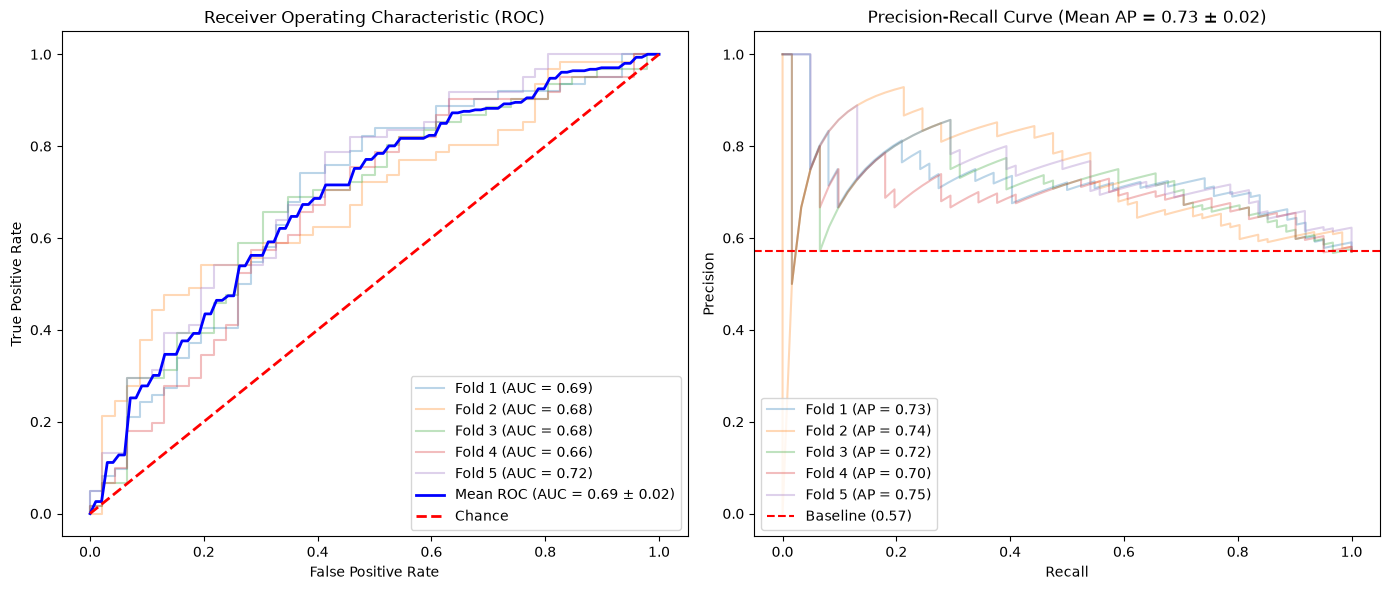

In [14]:
m_matrix_df.set_index("Sample_Name", inplace=True)
generate_evaluation_plots(m_matrix_df, pheno_df, chr_topologies, cell_cols)

In [3]:
epigenetic_drivers = pd.read_csv("/workspace/results/pd_ensemble_epigenetic_drivers.csv")

In [6]:
epigenetic_drivers.shape

(421114, 5)

In [7]:
epigenetic_drivers.head()

,IlmnID,Chromosome,Attention_Score,UCSC_RefGene_Name,UCSC_RefGene_Group
0,cg00176309,21,0.000301,NaN,NaN
1,cg24014805,21,0.000301,NaN,NaN
2,cg24943066,21,0.000301,NaN,NaN
3,cg01772743,21,0.000301,NaN,NaN
4,cg08039560,21,0.000301,NaN,NaN


In [5]:
epigenetic_drivers[epigenetic_drivers['UCSC_RefGene_Group'].isna()].shape

(96768, 5)

In [ ]:
!apt-get update && apt-get install -y bedtools

In [ ]:
%conda install -c conda-forge -c bioconda pybedtools gseapy

In [9]:
import pandas as pd
import pybedtools
import os

def map_distal_enhancers_to_genes(test_bed_path, output_mapped_path="mapped_genes.csv"):
    """
    Downloads hg19 RefSeq genes and maps intergenic CpGs to their closest target gene.
    """
    print("Downloading hg19 RefSeq gene bounds from UCSC...")
    # Fetch hg19 refGene table. Columns: 2=chrom, 4=txStart, 5=txEnd, 12=name2 (Gene Symbol)
    os.system("curl -s 'http://hgdownload.cse.ucsc.edu/goldenpath/hg19/database/refGene.txt.gz' | zcat | awk -v OFS='\t' '{print $3, $5, $6, $13}' > hg19_refseq.bed")
    
    # Sort the reference file (required for the closest function)
    os.system("sort -k1,1 -k2,2n hg19_refseq.bed > hg19_refseq_sorted.bed")
    
    # 1. Load your top 500 strict BED file and the reference into pybedtools
    enhancers = pybedtools.BedTool(test_bed_path)
    genes = pybedtools.BedTool("hg19_refseq_sorted.bed")
    
    print("Intersecting regions and calculating distances...")
    # 2. Find the closest gene. 
    # - d=True adds a column with the distance in base pairs.
    # - t='first' ensures we only get one gene per CpG to avoid duplicates.
    mapped = enhancers.closest(genes, d=True, t='first')
    
    # 3. Convert the results back to a Pandas DataFrame
    # Columns: [chr, start, end, name, ref_chr, ref_start, ref_end, Gene_Symbol, Distance]
    mapped_df = mapped.to_dataframe(
        names=['chr', 'start', 'end', 'cpg_id', 'ref_chr', 'ref_start', 'ref_end', 'target_gene', 'distance_bp']
    )
    
    # Filter out anything mapped to weird contigs and drop the temporary coordinate columns
    final_df = mapped_df[['cpg_id', 'chr', 'start', 'target_gene', 'distance_bp']].copy()
    final_df = final_df[final_df['target_gene'] != '.'] # Remove unmapped
    
    final_df.to_csv(output_mapped_path, index=False)
    print(f"Successfully mapped {len(final_df)} distal regions to target genes.")
    
    return final_df


In [10]:
mapped_enhancers_df = map_distal_enhancers_to_genes("/workspace/results/top_500_pd_enhancers_strict.bed")
print(mapped_enhancers_df.head())

Intersecting regions and calculating distances...
Successfully mapped 500 distal regions to target genes.
       cpg_id    chr     start   target_gene  distance_bp
0  cg12459059  chr21  10884747          TPTE        21994
1  cg23347501  chr21  10884968          TPTE        21773
2  cg06651563  chr21  15309845  LOC110091776         3646
3  cg25507885  chr21  15436259          LIPI        44872
4  cg16038510  chr21  15443106          LIPI        38025


In [ ]:
import pandas as pd

def _format_and_export_strict_bed(df, output_path):
    """Helper function to apply strict genomic formatting and export."""
    
    # 1. Clean Chromosome Names (prevents 'chrchr' bugs if 'chr' is already present)
    chroms = 'chr' + df['CHR'].astype(str).str.replace(r'^chr', '', regex=True, case=False)
    
    # 2. Build coordinates (0-based, half-open, ensure no negative starts)
    starts = (df['MAPINFO'].astype(int) - 1).clip(lower=0)
    ends = df['MAPINFO'].astype(int) + 1
    
    # 3. Create raw BED DataFrame (Strict 4 columns: no scores/decimals allowed)
    bed_df = pd.DataFrame({
        'chrom': chroms,
        'start': starts,
        'end': ends,
        'name': df['IlmnID']
    })
    
    # 4. Filter to standard human chromosomes only
    valid_chroms = [f'chr{i}' for i in range(1, 23)] + ['chrX', 'chrY']
    bed_df = bed_df[bed_df['chrom'].isin(valid_chroms)].copy()
    
    # 5. Sort biologically (chr1 -> chr22 -> X -> Y) and by start position
    bed_df['chrom'] = pd.Categorical(bed_df['chrom'], categories=valid_chroms, ordered=True)
    bed_df = bed_df.sort_values(['chrom', 'start']).dropna(subset=['chrom'])
    
    # 6. Export as plain text (no header, no index)
    bed_df.to_csv(output_path, sep='\t', header=False, index=False)
    print(f"Strict BED saved to {output_path} ({len(bed_df)} regions)")
    
    return bed_df

def export_strict_test_bed(drivers_csv_path, manifest_df, top_n=500, output_path="top_500_pd_enhancers_strict.bed"):
    """Extracts top unannotated GAT drivers and exports directly to strict BED."""
    print(f"Generating strict test BED from {drivers_csv_path}...")
    drivers_df = pd.read_csv(drivers_csv_path)
    
    # Filter for unannotated regions
    unannotated = drivers_df[
        drivers_df['UCSC_RefGene_Name'].isna() | 
        (drivers_df['UCSC_RefGene_Name'].astype(str).str.lower() == 'nan')
    ]
    
    # Get top drivers and merge with physical coordinates
    top_cpgs = unannotated.sort_values(by='Attention_Score', ascending=False).head(top_n)
    merged_df = top_cpgs.merge(manifest_df[['IlmnID', 'CHR', 'MAPINFO']], on='IlmnID', how='inner')
    
    return _format_and_export_strict_bed(merged_df, output_path)

def export_strict_background_bed(manifest_df, common_probes, output_path="gat_background_universe_strict.bed"):
    """Extracts the entire GAT probe universe and exports directly to strict BED."""
    print("Generating strict background BED from manifest...")
    
    # Filter manifest to only probes used in the neural network
    bg_df = manifest_df[manifest_df['IlmnID'].isin(common_probes)].copy()
    bg_df = bg_df.dropna(subset=['CHR', 'MAPINFO'])
    
    return _format_and_export_strict_bed(bg_df, output_path)


In [ ]:
test_bed = export_strict_test_bed(
    drivers_csv_path="/workspace/results/peg1/pd_ensemble_epigenetic_drivers.csv",
    manifest_df=manifest_df,
    top_n=500,
    output_path="/workspace/results/peg1/top_500_pd_enhancers_strict.bed"
)

bg_bed = export_strict_background_bed(
    manifest_df=manifest_df,
    common_probes=common_probes,
    output_path="/workspace/results/peg1/gat_background_universe_strict.bed"
)

In [16]:
drivers_df.shape

(421114, 5)

Extracting top annotated GAT drivers...
Consolidating with mapped distal enhancers...
 -> Annotated genes found: 221
 -> Distal enhancer genes found: 122
 -> Total unique genes for GSEA: 284

Running Enrichment against 12 databases...
Found 5 strictly significant terms (FDR < 0.05)
Found 113 nominaly significant terms (pvalue < 0.05)


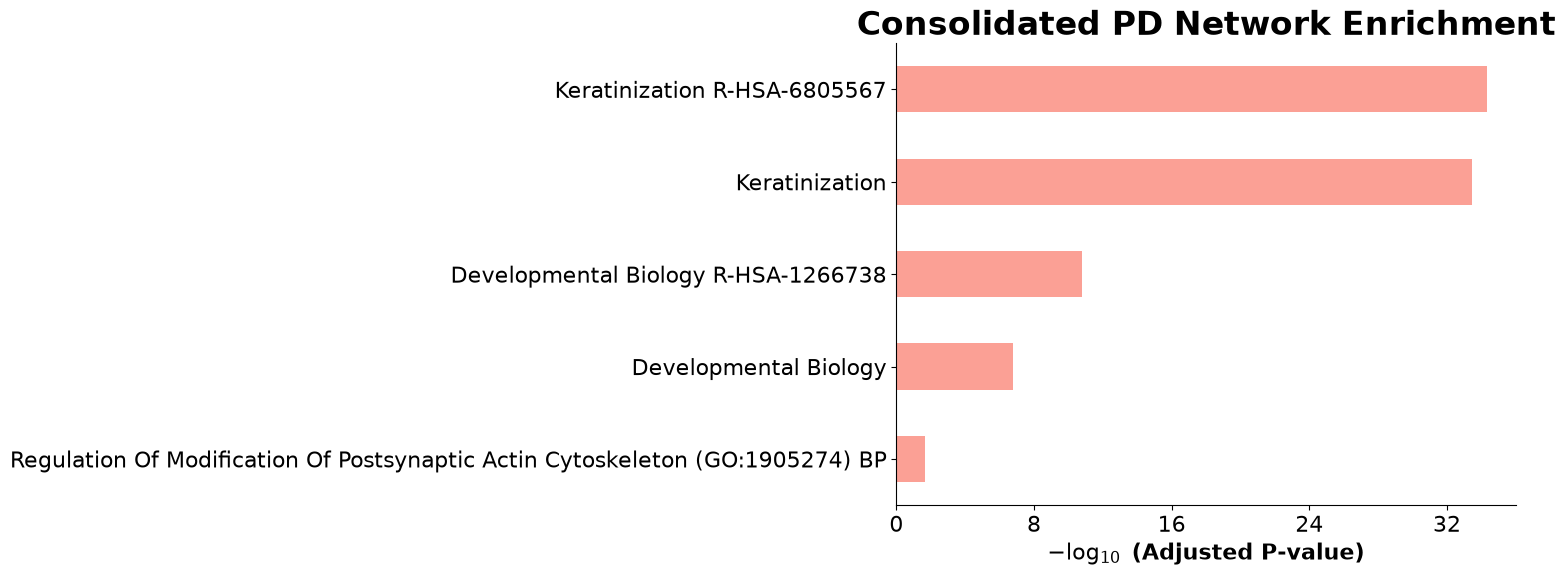

In [ ]:
import pandas as pd
import gseapy as gp
import matplotlib.pyplot as plt

# ==========================================
# 1. Extract the Top Annotated Genes
# ==========================================
print("Extracting top annotated GAT drivers...")
drivers_df = pd.read_csv("/workspace/results/pd_ensemble_epigenetic_drivers.csv")

# Isolate probes that HAVE a known gene annotation
annotated_df = drivers_df[
    drivers_df['UCSC_RefGene_Name'].notna() & 
    drivers_df['UCSC_RefGene_Name'].astype(str).str.lower() != 'nan'
]

top_annotated = annotated_df.sort_values(by='Attention_Score', ascending=False).head(3000) #2000

annotated_genes = []
for gene_string in top_annotated['UCSC_RefGene_Name']:
    # Illumina often lists multiple transcripts/genes per probe separated by ';'
    genes = str(gene_string).split(';')
    annotated_genes.extend(genes)

# ==========================================
# 2. Consolidate with Mapped Distal Genes
# ==========================================
print("Consolidating with mapped distal enhancers...")
# Apply the 50kb distance filter to the pybedtools output we made earlier
strict_mapped_df = mapped_enhancers_df[mapped_enhancers_df['distance_bp'] <= 50000]
distal_genes = strict_mapped_df['target_gene'].dropna().tolist()

# Combine both lists and convert to a set to ensure unique gene names
master_gene_list = list(set(annotated_genes + distal_genes))

print(f" -> Annotated genes found: {len(set(annotated_genes))}")
print(f" -> Distal enhancer genes found: {len(set(distal_genes))}")
print(f" -> Total unique genes for GSEA: {len(master_gene_list)}\n")

# ==========================================
# 3. Execute Consolidated GSEA
# ==========================================
databases = [
    'GO_Biological_Process_2026', 
    'Reactome_2022', 
    'KEGG_2021_Human',
    'Reactome_Pathways_2024',
    'GO_Molecular_Function_2026',
    'TRRUST_Transcription_Factors_2019',
    'TRANSFAC_and_JASPAR_PWMs',
    'ENCODE_TF_ChIP-seq_2015',
    'WikiPathways_2024_Human',
    'SynGO_2024',
    'WikiPathways_2024_Human',
    'Elsevier_Pathway_Collection'
]

print(f"Running Enrichment against {len(databases)} databases...")
enrichment = gp.enrichr(
    gene_list=master_gene_list,
    gene_sets=databases,
    organism='human',
    outdir=None 
)

results_df = enrichment.results

# Filter for strict FDR significance
fdr_sig = results_df[results_df['Adjusted P-value'] < 0.05]
print(f"Found {len(fdr_sig)} strictly significant terms (FDR < 0.05)")
print(f"Found {len(results_df[results_df['P-value'] < 0.05])} nominaly significant terms (pvalue < 0.05)")

if len(fdr_sig) > 0:
    # Plot the top 15 strictly significant pathways
    gp.barplot(
        enrichment.results, 
        column="Adjusted P-value", 
        title="Consolidated PD Network Enrichment",
        top_term=15, 
        figsize=(8, 6)
    )
    plt.show()
else:
    print("No terms survived FDR < 0.05. Check nominally significant terms:")
    print(results_df[results_df['P-value'] < 0.01][['Gene_set', 'Term', 'P-value', 'Overlap']].head(10))


In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

def plot_nominal_pathways(nominally_sig_df, significance, top_n=12):
    # 1. Prepare the DataFrame
    # Take the top N pathways based on P-value
    plot_df = nominally_sig_df.sort_values('P-value').head(top_n).copy()
    
    # Calculate -log10(p-value) for standard visualization
    plot_df['-log10(P-value)'] = -np.log10(plot_df['P-value'])
    
    # Extract the number of overlapping genes from the 'Overlap' column (e.g., "4/150" -> 4)
    plot_df['Gene_Count'] = plot_df['Overlap'].apply(lambda x: int(x.split('/')[0]))
    
    # Clean up GO terms (Remove the " (GO:0001234)" suffix for a cleaner y-axis)
    plot_df['Clean_Term'] = plot_df['Term'].apply(lambda x: x.split(' (GO:')[0] if 'GO:' in x else x)
    
    # Sort descending so the most significant is at the top of the plot
    plot_df = plot_df.sort_values('-log10(P-value)', ascending=False)
    
    # 2. Create the Figure
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(10, 6))
    
    # 3. Build the Scatter/Dot Plot
    bubble = sns.scatterplot(
        data=plot_df,
        x='-log10(P-value)',
        y='Clean_Term',
        size='Gene_Count',
        hue='Gene_set',        # Color by Database (GO, KEGG, Reactome)
        sizes=(150, 600),      # Control the min/max bubble sizes
        alpha=0.8,             # Slight transparency looks more professional
        palette="viridis",     # A colorblind-friendly, modern palette
        edgecolor='black',
        linewidth=0.5
    )
    
    # 4. Formatting and Labels
    plt.title("Pathway Enrichment of Distal Enhancers", fontsize=16, pad=15)
    plt.xlabel("-log$_{10}$({significance} P-value)", fontsize=12)
    plt.ylabel("") # Leave Y-label blank as the pathway names speak for themselves
    
    # Adjust the legend
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., title="Database & Gene Count")
    
    # Add a subtle vertical dashed line at P=0.01 (which is -log10(0.01) = 2.0)
    plt.axvline(x=2.0, color='red', linestyle='--', alpha=0.5, zorder=0)
    plt.text(2.02, plt.gca().get_ylim()[1]-0.2, 'P = 0.01', color='red', alpha=0.8, fontsize=10)
    
    plt.savefig(f"/workspace/results/{significance}_enhancer_dotplot.pdf", format="pdf", bbox_inches="tight")
    
    plt.show()


In [28]:
fdr_sig = results_df[results_df['Adjusted P-value'] < 0.05]
nominally_sig = results_df[(results_df['P-value'] < 0.05) & (results_df['Adjusted P-value'] >= 0.05)]

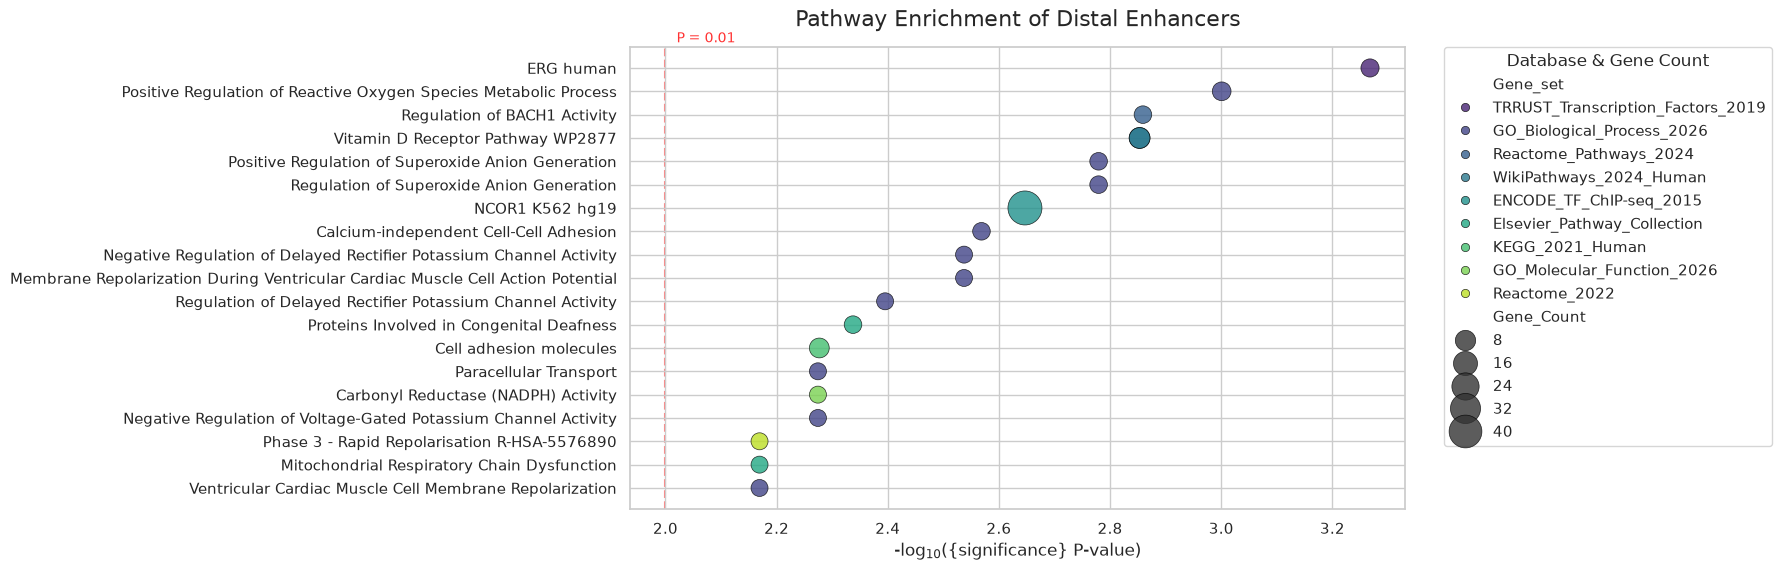

In [41]:
plot_nominal_pathways(nominally_sig, "nominal", top_n=20)

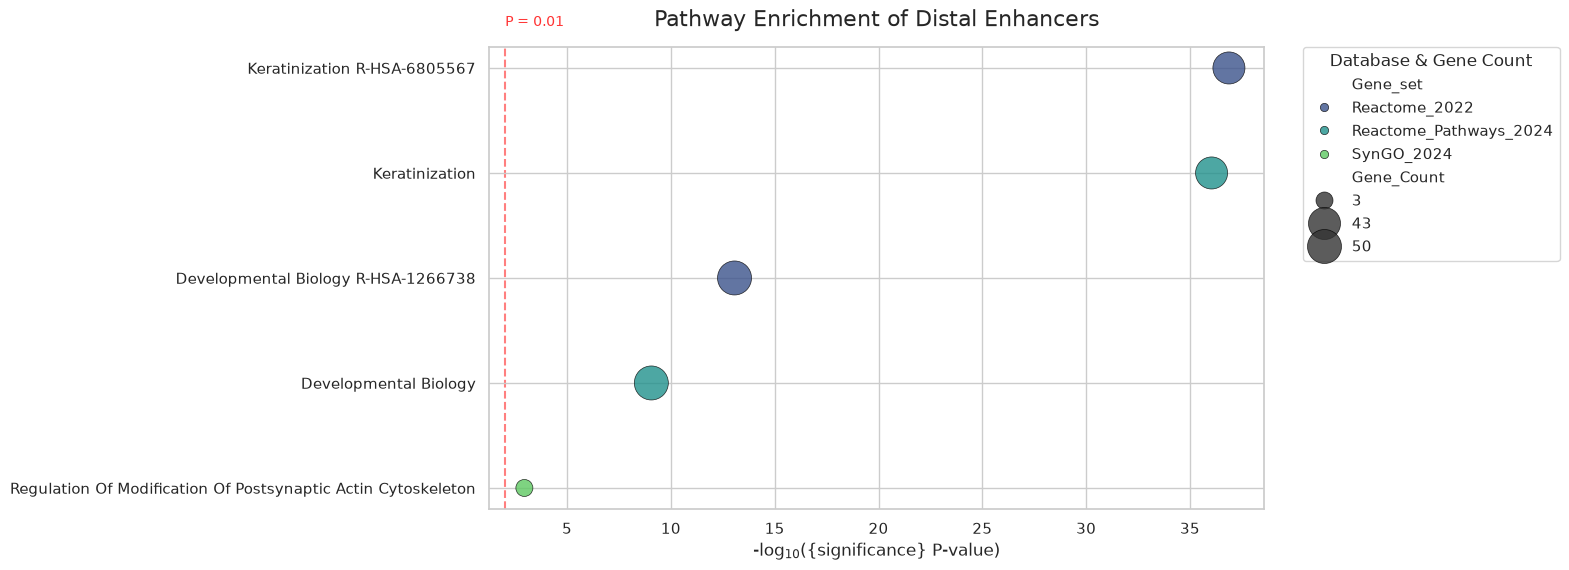

In [43]:
plot_nominal_pathways(fdr_sig, "corrected", top_n=20)

In [31]:
import pandas as pd
import numpy as np

def calculate_directionality(m_matrix_df, pheno_df, mapped_enhancers_df, output_csv="enhancer_directionality.csv"):
    """
    Calculates differential methylation (Delta M and Delta Beta) for the top GAT-selected CpGs.
    """
    print("Extracting target CpGs...")
    # Get the exact CpG IDs from your BED/Mapping output
    target_cpgs = mapped_enhancers_df['cpg_id'].unique().tolist()
    
    # Subset the methylation matrix to only include these top drivers
    sub_matrix = m_matrix_df[target_cpgs]
    
    # Split patient indices based on phenotype
    pd_indices = pheno_df.index[pheno_df['Sample_Group'] == 'PD'].tolist()
    ctrl_indices = pheno_df.index[pheno_df['Sample_Group'] == 'Control'].tolist()
    
    print("Calculating group means...")
    # Calculate Mean M-values
    mean_m_pd = sub_matrix.loc[pd_indices].mean(axis=0)
    mean_m_ctrl = sub_matrix.loc[ctrl_indices].mean(axis=0)
    
    # Calculate Delta M (Log2 Fold Change proxy)
    delta_m = mean_m_pd - mean_m_ctrl
    
    print("Converting to Beta values for clinical interpretability...")
    # Convert Mean M-values back to Beta-values using the inverse logit formula: Beta = 2^M / (2^M + 1)
    mean_beta_pd = (2 ** mean_m_pd) / ((2 ** mean_m_pd) + 1)
    mean_beta_ctrl = (2 ** mean_m_ctrl) / ((2 ** mean_m_ctrl) + 1)
    
    # Calculate Delta Beta (Absolute percentage shift)
    delta_beta = mean_beta_pd - mean_beta_ctrl
    
    # Compile the results
    results = pd.DataFrame({
        'cpg_id': target_cpgs,
        'Mean_M_PD': mean_m_pd,
        'Mean_M_Control': mean_m_ctrl,
        'Delta_M': delta_m,
        'Mean_Beta_PD': mean_beta_pd,
        'Mean_Beta_Control': mean_beta_ctrl,
        'Delta_Beta': delta_beta
    })
    
    # Classify the biological direction based on Delta Beta
    # A positive Delta Beta indicates the region gained methylation in PD
    results['Direction'] = np.where(results['Delta_Beta'] > 0, 'Hypermethylated', 'Hypomethylated')
    
    # Merge back with the target genes we mapped via pybedtools
    final_df = pd.merge(results, mapped_enhancers_df[['cpg_id', 'target_gene', 'distance_bp']], on='cpg_id', how='inner')
    
    # Sort by the largest absolute Delta Beta (strongest clinical effect size)
    final_df['Abs_Delta_Beta'] = final_df['Delta_Beta'].abs()
    final_df = final_df.sort_values('Abs_Delta_Beta', ascending=False).drop(columns=['Abs_Delta_Beta'])
    
    final_df.to_csv(output_csv, index=False)
    print(f"Directionality calculated! Saved to {output_csv}")
    
    return final_df



In [32]:
pheno_path = "/workspace/data/GSE111629_pheno_data.parquet"
m_matrix_path = "/workspace/data/GSE111629_m_matrix_full_reduced.parquet"

pheno_df = pd.read_parquet(pheno_path)
m_matrix_df = pd.read_parquet(m_matrix_path)

m_matrix_df.set_index("Sample_Name", inplace=True)

diff_meth_df = calculate_directionality(m_matrix_df, pheno_df, mapped_enhancers_df)
print(diff_meth_df[['target_gene', 'Delta_Beta', 'Direction']].head())

Extracting target CpGs...
Calculating group means...
Converting to Beta values for clinical interpretability...
Directionality calculated! Saved to enhancer_directionality.csv
    target_gene  Delta_Beta        Direction
422     SLC19A1    0.036568  Hypermethylated
164       RIPK4   -0.029664   Hypomethylated
72        OLIG2   -0.026905   Hypomethylated
382   LINC00334   -0.021442   Hypomethylated
252        SIK1    0.015927  Hypermethylated


In [33]:
diff_meth_df.to_csv("/workspace/results/diff_meth_df.csv")

In [25]:
%conda install statsmodels

2 channel Terms of Service accepted
Retrieving notices: done
Channels:
 - defaults
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 26.5.3
    latest version: 26.7.1

Please update conda by running

    $ conda self update



## Package Plan ##

  environment location: /opt/conda/envs/rapids-env

  added / updated specs:
    - statsmodels


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    ca-certificates-2026.8.13  |       h06a4308_0         107 KB
    patsy-1.0.2                |  py313h06a4308_0         518 KB
    statsmodels-0.14.6         |  py313h47b2149_0        11.6 MB
    ------------------------------------------------------------
                                           Total:        12.2 MB

The following NEW packages will be INSTALLED:

  patsy              pkgs/main/linux-64::patsy-1.0.2-py313h06a4308_0 
 

In [34]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests

def build_clinical_master_table(m_matrix_df, pheno_df, mapped_enhancers_df, pathway_results_df, output_csv="/workspace/results/clinical_translation_master.csv"):
    
    # ---------------------------------------------------------
    # PART 1: Strict Differential Methylation (Stats + Effect Size)
    # ---------------------------------------------------------
    print("Calculating statistical differential methylation...")
    target_cpgs = mapped_enhancers_df['cpg_id'].unique().tolist()
    sub_matrix = m_matrix_df[target_cpgs]
    
    pd_indices = pheno_df.index[pheno_df['Sample_Group'] == 'PD'].tolist()
    ctrl_indices = pheno_df.index[pheno_df['Sample_Group'] == 'Control'].tolist()
    
    results_list = []
    for cpg in target_cpgs:
        pd_vals = sub_matrix.loc[pd_indices, cpg]
        ctrl_vals = sub_matrix.loc[ctrl_indices, cpg]
        
        # Means and Delta M
        mean_m_pd = pd_vals.mean()
        mean_m_ctrl = ctrl_vals.mean()
        delta_m = mean_m_pd - mean_m_ctrl
        
        # Clinical Beta conversion
        mean_beta_pd = (2 ** mean_m_pd) / ((2 ** mean_m_pd) + 1)
        mean_beta_ctrl = (2 ** mean_m_ctrl) / ((2 ** mean_m_ctrl) + 1)
        delta_beta = mean_beta_pd - mean_beta_ctrl
        
        # Statistical Test (Welch's t-test for unequal variances)
        stat, p_val = ttest_ind(pd_vals, ctrl_vals, equal_var=False)
        
        results_list.append({
            'cpg_id': cpg,
            'Delta_Beta': delta_beta,
            'Direction': 'Hypermethylated' if delta_beta > 0 else 'Hypomethylated',
            'P_Value': p_val
        })
        
    diff_df = pd.DataFrame(results_list)
    
    # Apply Benjamini-Hochberg FDR correction
    _, diff_df['FDR_q_val'], _, _ = multipletests(diff_df['P_Value'], method='fdr_bh')
    
    # Merge with the BEDTools gene mapping
    cpg_gene_df = pd.merge(diff_df, mapped_enhancers_df[['cpg_id', 'target_gene', 'distance_bp']], on='cpg_id', how='inner')
    
    # ---------------------------------------------------------
    # PART 2: Pathway Mapping
    # ---------------------------------------------------------
    print("Mapping specific CpGs to Enrichment Terms...")
    
    # Create a dictionary mapping each gene to its discovered pathways
    # gseapy outputs genes as a string separated by semicolons: "GENEA;GENEB"
    gene_to_pathways = {}
    for _, row in pathway_results_df.iterrows():
        term = row['Term']
        genes_in_term = str(row['Genes']).split(';')
        for gene in genes_in_term:
            if gene not in gene_to_pathways:
                gene_to_pathways[gene] = []
            gene_to_pathways[gene].append(term)
            
    # Map the pathways back to the CpG-Gene dataframe
    # If a gene hits multiple pathways, join them with a " | " for clean reading
    cpg_gene_df['Enriched_Pathways'] = cpg_gene_df['target_gene'].apply(
        lambda x: " | ".join(gene_to_pathways.get(x, ["No Significant Pathway"]))
    )
    
    # ---------------------------------------------------------
    # PART 3: Final Formatting
    # ---------------------------------------------------------
    # Sort by the most statistically significant CpGs
    master_table = cpg_gene_df.sort_values('P_Value', ascending=True)
    
    # Reorder columns for clinical readability
    cols = ['cpg_id', 'target_gene', 'distance_bp', 'Direction', 'Delta_Beta', 'P_Value', 'FDR_q_val', 'Enriched_Pathways']
    master_table = master_table[cols]
    
    master_table.to_csv(output_csv, index=False)
    print(f"Master clinical translation table generated! Saved to {output_csv}")
    
    return master_table



In [35]:

clinical_master_df = build_clinical_master_table(
    m_matrix_df=m_matrix_df, 
    pheno_df=pheno_df, 
    mapped_enhancers_df=strict_mapped_df, 
    pathway_results_df=results_df  # Use your filtered gseapy results here
)

Calculating statistical differential methylation...
Mapping specific CpGs to Enrichment Terms...
Master clinical translation table generated! Saved to /workspace/results/clinical_translation_master.csv


In [36]:
clinical_master_df.head()

,cpg_id,target_gene,distance_bp,Direction,Delta_Beta,P_Value,FDR_q_val,Enriched_Pathways
216,cg21895314,CRYAA,788,Hypomethylated,-0.013064,0.000893,0.270489,Negative Regulation of Intracellular Transport...
278,cg22669624,RRP1,3946,Hypermethylated,0.007934,0.001506,0.270489,Regulation of Transcription by RNA Polymerase ...
203,cg23256367,WDR4,2585,Hypermethylated,0.012116,0.001646,0.270489,RNA Modification (GO:0009451) | TRNA Methylati...
15,cg20545330,USP25,1886,Hypermethylated,0.002225,0.003080,0.294346,Negative Regulation of Response to Oxidative S...
118,cg25940392,SIM2,6715,Hypermethylated,0.010021,0.003822,0.294346,Nervous System Development (GO:0007399) | Regu...


In [37]:
clinical_master_df.head(10)

,cpg_id,target_gene,distance_bp,Direction,Delta_Beta,P_Value,FDR_q_val,Enriched_Pathways
216,cg21895314,CRYAA,788,Hypomethylated,-0.013064,0.000893,0.270489,Negative Regulation of Intracellular Transport...
278,cg22669624,RRP1,3946,Hypermethylated,0.007934,0.001506,0.270489,Regulation of Transcription by RNA Polymerase ...
203,cg23256367,WDR4,2585,Hypermethylated,0.012116,0.001646,0.270489,RNA Modification (GO:0009451) | TRNA Methylati...
15,cg20545330,USP25,1886,Hypermethylated,0.002225,0.003080,0.294346,Negative Regulation of Response to Oxidative S...
118,cg25940392,SIM2,6715,Hypermethylated,0.010021,0.003822,0.294346,Nervous System Development (GO:0007399) | Regu...
275,cg06279535,PDXK,3010,Hypermethylated,0.008037,0.004417,0.294346,Metabolic Compound Salvage (GO:0043094) | Meta...
345,cg08823554,PTTG1IP,308,Hypomethylated,-0.002736,0.004512,0.294346,"Negative Regulation of DNA Damage Response, Si..."
157,cg06230839,RIPK4,2680,Hypomethylated,-0.029664,0.005184,0.294346,Morphogenesis of an Epithelium (GO:0002009) | ...
348,cg02579389,LINC00163,2774,Hypermethylated,0.008443,0.005373,0.294346,KDM5B H1-hESC hg19 | CBX8 K562 hg19 | POLR2Aph...
107,cg03239638,DOP1B,0,Hypomethylated,-0.011238,0.007431,0.336317,Cognition (GO:0050890) | Regulation of Retrogr...


In [38]:
clinical_master_df.to_csv("/workspace/results/clinical_translation_master.csv", index=False)

In [47]:
%conda install conda-forge::adjusttext -y

2 channel Terms of Service accepted
Channels:
 - defaults
 - conda-forge
Platform: linux-64
Solving environment: done

## Package Plan ##

  environment location: /opt/conda/envs/rapids-env

  added / updated specs:
    - conda-forge::adjusttext


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    adjusttext-1.4.0           |     pyhd8ed1ab_1          20 KB  conda-forge
    ------------------------------------------------------------
                                           Total:          20 KB

The following NEW packages will be INSTALLED:

  adjusttext         conda-forge/noarch::adjusttext-1.4.0-pyhd8ed1ab_1 



                                                                               
Preparing transaction: done
Verifying transaction: done
Executing transaction: done
WARNING conda.conda_pypi.main:notify_externally_managed_future(156): 
  Did you know? You can install many PyPI p

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text

def plot_directional_manhattan(master_df, manifest_df, top_n_labels=15, output_pdf="/workspace/results/peg1/chromosomal_methylation.pdf"):
    print("Merging physical coordinates for plotting...")
    
    # 1. Merge master table with manifest to get CHR and MAPINFO
    plot_df = pd.merge(
        master_df, 
        manifest_df[['IlmnID', 'CHR', 'MAPINFO']], 
        left_on='cpg_id', 
        right_on='IlmnID', 
        how='inner'
    )
    
    # Clean and sort chromosomes biologically (1-22)
    plot_df['CHR'] = plot_df['CHR'].astype(str).str.replace('chr', '', case=False)
    plot_df = plot_df[plot_df['CHR'].isin([str(i) for i in range(1, 23)])]
    plot_df['CHR'] = plot_df['CHR'].astype(int)
    plot_df = plot_df.sort_values(['CHR', 'MAPINFO']).reset_index(drop=True)
    
    # 2. Calculate Continuous X-Axis Coordinates
    # To plot chromosomes side-by-side, we add the max position of the previous chromosome
    chr_lengths = plot_df.groupby('CHR')['MAPINFO'].max()
    chr_offsets = chr_lengths.cumsum() - chr_lengths
    plot_df['plot_pos'] = plot_df.apply(lambda row: row['MAPINFO'] + chr_offsets[row['CHR']], axis=1)
    
    # 3. Calculate CpG Counts per Target Gene
    # This fulfills the request to show the amount of CpGs per gene
    gene_counts = plot_df.groupby('target_gene').size().to_dict()
    plot_df['gene_label'] = plot_df['target_gene'].apply(lambda x: f"{x} (n={gene_counts.get(x, 1)})")
    
    # 4. Initialize the Figure
    sns.set_theme(style="white")
    fig, ax = plt.subplots(figsize=(16, 7))
    
    # Define clinical colors
    color_map = {'Hypermethylated': '#E64B35', 'Hypomethylated': '#4DBBD5'}
    
    # 5. Plot the Data Points
    for direction, color in color_map.items():
        subset = plot_df[plot_df['Direction'] == direction]
        ax.scatter(
            subset['plot_pos'], 
            subset['Delta_Beta'], 
            c=color, 
            label=direction, 
            alpha=0.7, 
            s=40, 
            edgecolors='white', 
            linewidth=0.5
        )
        
    # 6. Formatting the X-Axis to show Chromosomes
    # Calculate the center position of each chromosome for the x-ticks
    chr_centers = plot_df.groupby('CHR')['plot_pos'].mean()
    ax.set_xticks(chr_centers.values)
    ax.set_xticklabels(chr_centers.index, fontsize=10)
    
    # Alternate background shading for visual chromosome separation
    for i, chrom in enumerate(chr_centers.index):
        if i % 2 == 0:
            chr_min = plot_df[plot_df['CHR'] == chrom]['plot_pos'].min()
            chr_max = plot_df[plot_df['CHR'] == chrom]['plot_pos'].max()
            ax.axvspan(chr_min, chr_max, color='grey', alpha=0.08, zorder=0)

    # Add a horizontal line at 0 (No change)
    ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.8)
    
    # 7. Add Labels for the Top Genes
    # Select the most significant genes based on FDR or absolute Delta Beta
    top_hits = plot_df.sort_values('P_Value').drop_duplicates('target_gene').head(top_n_labels)
    
    texts = []
    for _, row in top_hits.iterrows():
        texts.append(ax.text(
            row['plot_pos'], 
            row['Delta_Beta'], 
            row['gene_label'], 
            fontsize=9, 
            fontweight='bold',
            color='black'
        ))
        
    # Prevent text from overlapping using adjustText
    print("Optimizing label placement...")
    adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

    # 8. Final Polish
    ax.set_title("Directional Chromosomal Map of Parkinson's Epigenetic Drivers", fontsize=16, pad=15)
    ax.set_xlabel("Chromosome", fontsize=12, labelpad=10)
    ax.set_ylabel(r"Effect Size ($\Delta \beta$)", fontsize=12, labelpad=10)
    
    # Clean up borders
    sns.despine()
    ax.legend(title="Biological Mechanism", loc='upper right', frameon=True)
    
    plt.tight_layout()
    plt.savefig(output_pdf, format="pdf", dpi=300)
    plt.show()


In [ ]:
manifest_path = "/workspace/data/infinium450k_manifest.parquet"
manifest_df = pd.read_parquet(manifest_path)


In [54]:
clinical_master_df.head(10)

,cpg_id,target_gene,distance_bp,Direction,Delta_Beta,P_Value,FDR_q_val,Enriched_Pathways
216,cg21895314,CRYAA,788,Hypomethylated,-0.013064,0.000893,0.270489,Negative Regulation of Intracellular Transport...
278,cg22669624,RRP1,3946,Hypermethylated,0.007934,0.001506,0.270489,Regulation of Transcription by RNA Polymerase ...
203,cg23256367,WDR4,2585,Hypermethylated,0.012116,0.001646,0.270489,RNA Modification (GO:0009451) | TRNA Methylati...
15,cg20545330,USP25,1886,Hypermethylated,0.002225,0.003080,0.294346,Negative Regulation of Response to Oxidative S...
118,cg25940392,SIM2,6715,Hypermethylated,0.010021,0.003822,0.294346,Nervous System Development (GO:0007399) | Regu...
275,cg06279535,PDXK,3010,Hypermethylated,0.008037,0.004417,0.294346,Metabolic Compound Salvage (GO:0043094) | Meta...
345,cg08823554,PTTG1IP,308,Hypomethylated,-0.002736,0.004512,0.294346,"Negative Regulation of DNA Damage Response, Si..."
157,cg06230839,RIPK4,2680,Hypomethylated,-0.029664,0.005184,0.294346,Morphogenesis of an Epithelium (GO:0002009) | ...
348,cg02579389,LINC00163,2774,Hypermethylated,0.008443,0.005373,0.294346,KDM5B H1-hESC hg19 | CBX8 K562 hg19 | POLR2Aph...
107,cg03239638,DOP1B,0,Hypomethylated,-0.011238,0.007431,0.336317,Cognition (GO:0050890) | Regulation of Retrogr...


Merging physical coordinates for plotting...
Optimizing label placement...


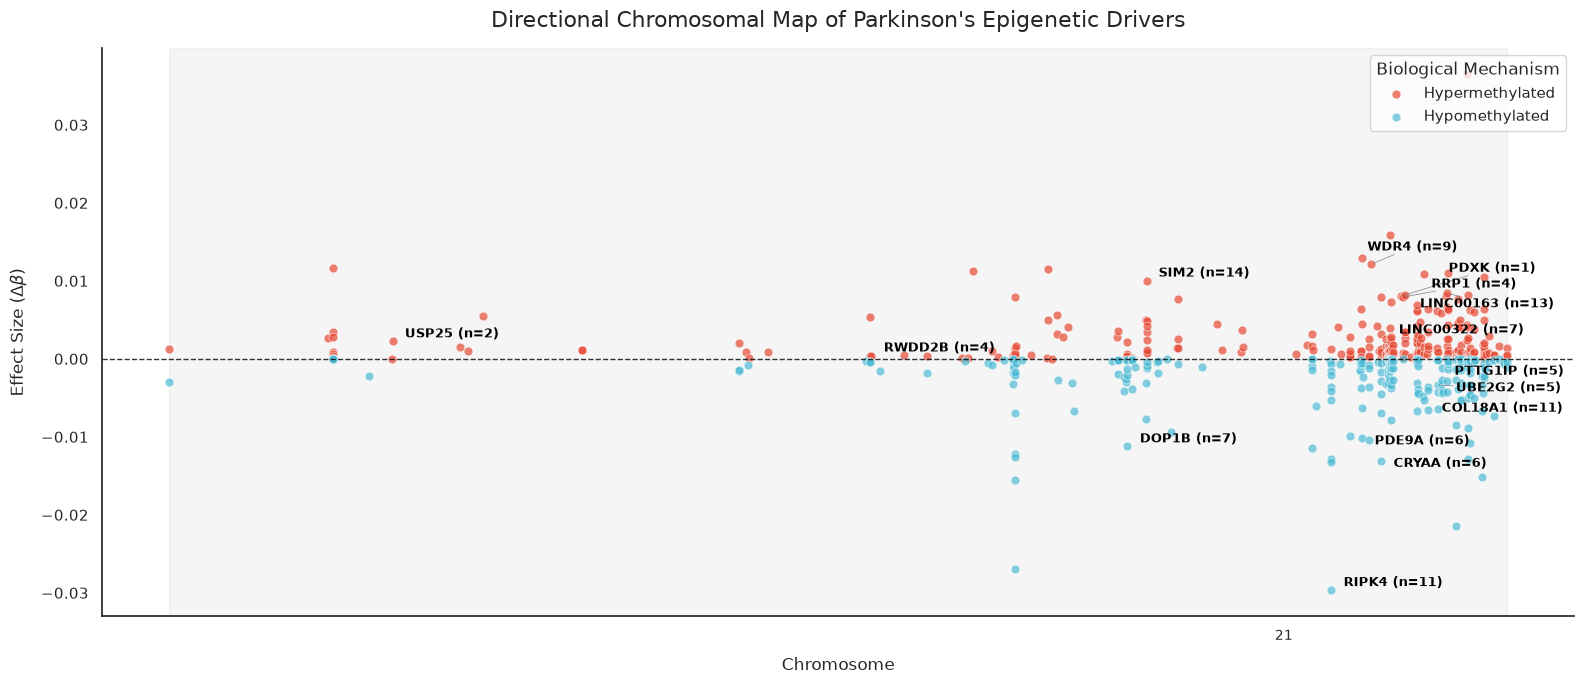

In [55]:
plot_directional_manhattan(clinical_master_df, manifest_df, top_n_labels=15)

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def plot_clinical_ideograms(clinical_df, manifest_df, output_pdf="/workspace/results/peg1/chromosome_ideograms.pdf"):
    print("Fetching hg19 cytoband data from UCSC...")
    if not os.path.exists("cytoBand_hg19.txt.gz"):
        os.system("curl -s 'http://hgdownload.cse.ucsc.edu/goldenpath/hg19/database/cytoBand.txt.gz' > cytoBand_hg19.txt.gz")
        
    cytobands = pd.read_csv("cytoBand_hg19.txt.gz", sep='\t', header=None, 
                            names=['chrom', 'start', 'end', 'name', 'stain'])
    
    # Filter to standard autosomes and map vertical Y-positions
    chroms = [f"chr{i}" for i in range(1, 23)]
    cytobands = cytobands[cytobands['chrom'].isin(chroms)]
    y_positions = {chrom: i * 2 for i, chrom in enumerate(chroms)}
    
    # Giemsa stain hex codes
    stain_colors = {
        'gneg': '#FFFFFF', 'gpos25': '#E0E0E0', 'gpos50': '#BDBDBD',
        'gpos75': '#757575', 'gpos100': '#212121', 'acen': '#D32F2F',
        'gvar': '#9E9E9E', 'stalk': '#EEEEEE'
    }

    fig, ax = plt.subplots(figsize=(14, 12))
    
    # 1. Draw the Chromosome Ideograms
    for _, row in cytobands.iterrows():
        ax.add_patch(patches.Rectangle(
            (row['start'], y_positions[row['chrom']] - 0.3),
            row['end'] - row['start'], 0.6,
            facecolor=stain_colors.get(row['stain'], '#FFFFFF'),
            edgecolor='black', linewidth=0.5, zorder=1
        ))

    # 2. Merge and Plot Clinical Data
    print("Overlaying epigenetic drivers...")
    plot_df = pd.merge(clinical_df, manifest_df[['IlmnID', 'CHR', 'MAPINFO']], 
                       left_on='cpg_id', right_on='IlmnID', how='inner')
    
    plot_df['chrom'] = 'chr' + plot_df['CHR'].astype(str)
    plot_df = plot_df[plot_df['chrom'].isin(chroms)]

    # Plot Hypermethylated (Above chromosome)
    hyper = plot_df[plot_df['Direction'] == 'Hypermethylated']
    ax.scatter(hyper['MAPINFO'], hyper['chrom'].map(y_positions) + 0.5, 
               marker='v', color='#E64B35', s=30, zorder=2, label="Hypermethylated")

    # Plot Hypomethylated (Below chromosome)
    hypo = plot_df[plot_df['Direction'] == 'Hypomethylated']
    ax.scatter(hypo['MAPINFO'], hypo['chrom'].map(y_positions) - 0.5, 
               marker='^', color='#4DBBD5', s=30, zorder=2, label="Hypomethylated")

    # 3. Formatting
    ax.set_yticks([y_positions[c] for c in chroms])
    ax.set_yticklabels(chroms, fontsize=10)
    ax.set_xlabel("Genomic Position (bp, hg19)", fontsize=12)
    ax.set_title("Chromosomal Distribution of Parkinson's Epigenetic Drivers", fontsize=16, pad=20)
    
    # Clean up plot area
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    
    # Handle duplicate labels in legend
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), loc='upper right')

    plt.tight_layout()
    plt.savefig(output_pdf, format="pdf", dpi=300)
    plt.show()



Fetching hg19 cytoband data from UCSC...
Overlaying epigenetic drivers...


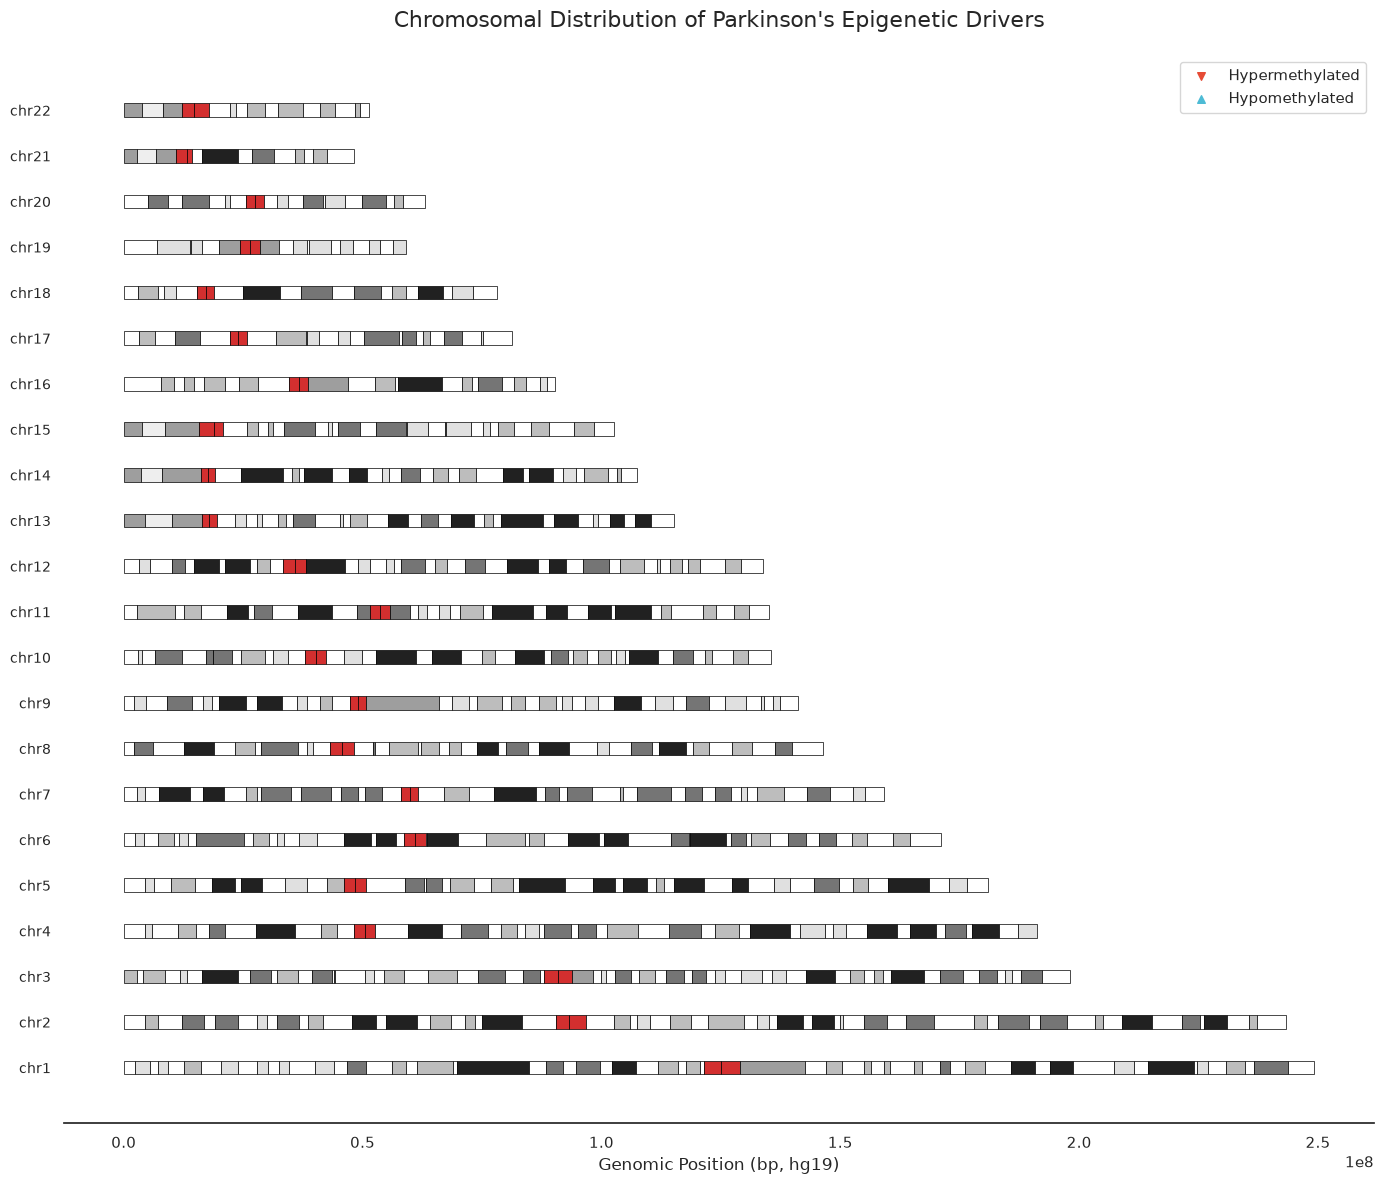

In [57]:
plot_clinical_ideograms(clinical_master_df, manifest_df)

In [ ]:
import os
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from adjustText import adjust_text

def analyze_and_plot_pathway(target_term, master_df, manifest_df, pheno_df, m_matrix_df, output_pdf="pathway_ideogram.pdf"):
    print(f"Isolating network for: {target_term}")
    
    # ==========================================
    # 1. Filter and Merge
    # ==========================================
    # Extract only the CpGs associated with the target pathway
    pathway_df = master_df[master_df['Enriched_Pathways'].str.contains(target_term, na=False, regex=False)].copy()
    
    # Merge physical coordinates
    pathway_df = pd.merge(
        pathway_df, 
        manifest_df[['IlmnID', 'CHR', 'MAPINFO']], 
        left_on='cpg_id', right_on='IlmnID', how='inner'
    )
    
    pathway_df['CHR'] = pathway_df['CHR'].astype(str).str.replace('chr', '', case=False)
    valid_chroms = [str(i) for i in range(1, 23)]
    pathway_df = pathway_df[pathway_df['CHR'].isin(valid_chroms)]
    
    # ==========================================
    # 2. Chromosome-Level Statistics
    # ==========================================
    print("Calculating chromosomal fold-change statistics...")
    stats_records = []
    
    for chrom, group in pathway_df.groupby('CHR'):
        cpgs = group['cpg_id'].tolist()
        
        # Calculate the spread of the effect sizes for this chromosome
        mean_db = group['Delta_Beta'].mean()
        sd_db = group['Delta_Beta'].std() if len(cpgs) > 1 else 0.0
        
        # Calculate the true patient-level aggregate burden for the t-test
        # Convert M-values to Beta-values: Beta = 2^M / (2^M + 1)
        patient_betas = (2 ** m_matrix_df[cpgs]) / ((2 ** m_matrix_df[cpgs]) + 1)
        chr_burden = patient_betas.mean(axis=1) # The aggregated pathway score per patient on this chromosome
        
        pd_vals = chr_burden[pheno_df['Sample_Group'] == 'PD']
        ctrl_vals = chr_burden[pheno_df['Sample_Group'] == 'Control']
        
        # Welch's t-test for the chromosome's aggregate fold change
        stat, p_val = ttest_ind(pd_vals, ctrl_vals, equal_var=False)
        
        stats_records.append({
            'Chromosome': chrom,
            'Target_Genes': ", ".join(group['target_gene'].unique()),
            'CpG_Count': len(cpgs),
            'Mean_Delta_Beta': mean_db,
            'SD_Delta_Beta': sd_db,
            'Nominal_P': p_val
        })
        
    stats_df = pd.DataFrame(stats_records)
    
    # Apply Benjamini-Hochberg FDR correction across the chromosomes
    if len(stats_df) > 0:
        _, stats_df['FDR_Q'] = multipletests(stats_df['Nominal_P'], method='fdr_bh')[:2]
        
    stats_df = stats_df.sort_values('Nominal_P')
    
    # ==========================================
    # 3. Targeted Ideogram Plotting
    # ==========================================
    print("Generating pathway-specific ideogram...")
    if not os.path.exists("cytoBand_hg19.txt.gz"):
        os.system("curl -s 'http://hgdownload.cse.ucsc.edu/goldenpath/hg19/database/cytoBand.txt.gz' > cytoBand_hg19.txt.gz")
        
    cytobands = pd.read_csv("cytoBand_hg19.txt.gz", sep='\t', header=None, names=['chrom', 'start', 'end', 'name', 'stain'])
    chroms = [f"chr{i}" for i in range(1, 23)]
    cytobands = cytobands[cytobands['chrom'].isin(chroms)]
    y_positions = {chrom: i * 2 for i, chrom in enumerate(chroms)}
    
    stain_colors = {
        'gneg': '#FFFFFF', 'gpos25': '#E0E0E0', 'gpos50': '#BDBDBD',
        'gpos75': '#757575', 'gpos100': '#212121', 'acen': '#D32F2F',
        'gvar': '#9E9E9E', 'stalk': '#EEEEEE'
    }

    fig, ax = plt.subplots(figsize=(14, 12))
    
    # Draw physical chromosomes
    for _, row in cytobands.iterrows():
        ax.add_patch(patches.Rectangle(
            (row['start'], y_positions[row['chrom']] - 0.3),
            row['end'] - row['start'], 0.6,
            facecolor=stain_colors.get(row['stain'], '#FFFFFF'),
            edgecolor='black', linewidth=0.5, zorder=1
        ))

    pathway_df['chrom_label'] = 'chr' + pathway_df['CHR'].astype(str)

    # Plot Hypermethylated
    hyper = pathway_df[pathway_df['Direction'] == 'Hypermethylated']
    ax.scatter(hyper['MAPINFO'], hyper['chrom_label'].map(y_positions) + 0.6, 
               marker='v', color='#E64B35', s=60, zorder=2, label="Hypermethylated")

    # Plot Hypomethylated
    hypo = pathway_df[pathway_df['Direction'] == 'Hypomethylated']
    ax.scatter(hypo['MAPINFO'], hypo['chrom_label'].map(y_positions) - 0.6, 
               marker='^', color='#4DBBD5', s=60, zorder=2, label="Hypomethylated")

    # Add Gene Labels
    texts = []
    # Group by gene to place one label per gene cluster to avoid severe overcrowding
    for gene, group in pathway_df.groupby('target_gene'):
        rep_row = group.iloc[0] # Take the first CpG's location for the label anchor
        y_base = y_positions[rep_row['chrom_label']]
        y_offset = 1.0 if rep_row['Direction'] == 'Hypermethylated' else -1.0
        
        texts.append(ax.text(
            rep_row['MAPINFO'], 
            y_base + y_offset, 
            f"{gene} (n={len(group)})", 
            fontsize=10, fontweight='bold'
        ))

    adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

    # Formatting
    ax.set_yticks([y_positions[c] for c in chroms])
    ax.set_yticklabels(chroms, fontsize=10)
    ax.set_xlabel("Genomic Position (bp, hg19)", fontsize=12)
    
    # Word-wrap the title if the pathway name is extremely long
    clean_title = target_term.split(' (GO:')[0] if 'GO:' in target_term else target_term
    ax.set_title(f"Spatial Disruption of '{clean_title}' in PD", fontsize=16, pad=20)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), loc='upper right')

    plt.tight_layout()
    plt.savefig(output_pdf, format="pdf", bbox_inches="tight")
    plt.show()

    return stats_df

Isolating network for: Regulation Of Modification Of Postsynaptic Actin Cytoskeleton (GO:1905274) BP
Calculating chromosomal fold-change statistics...
Generating pathway-specific ideogram...


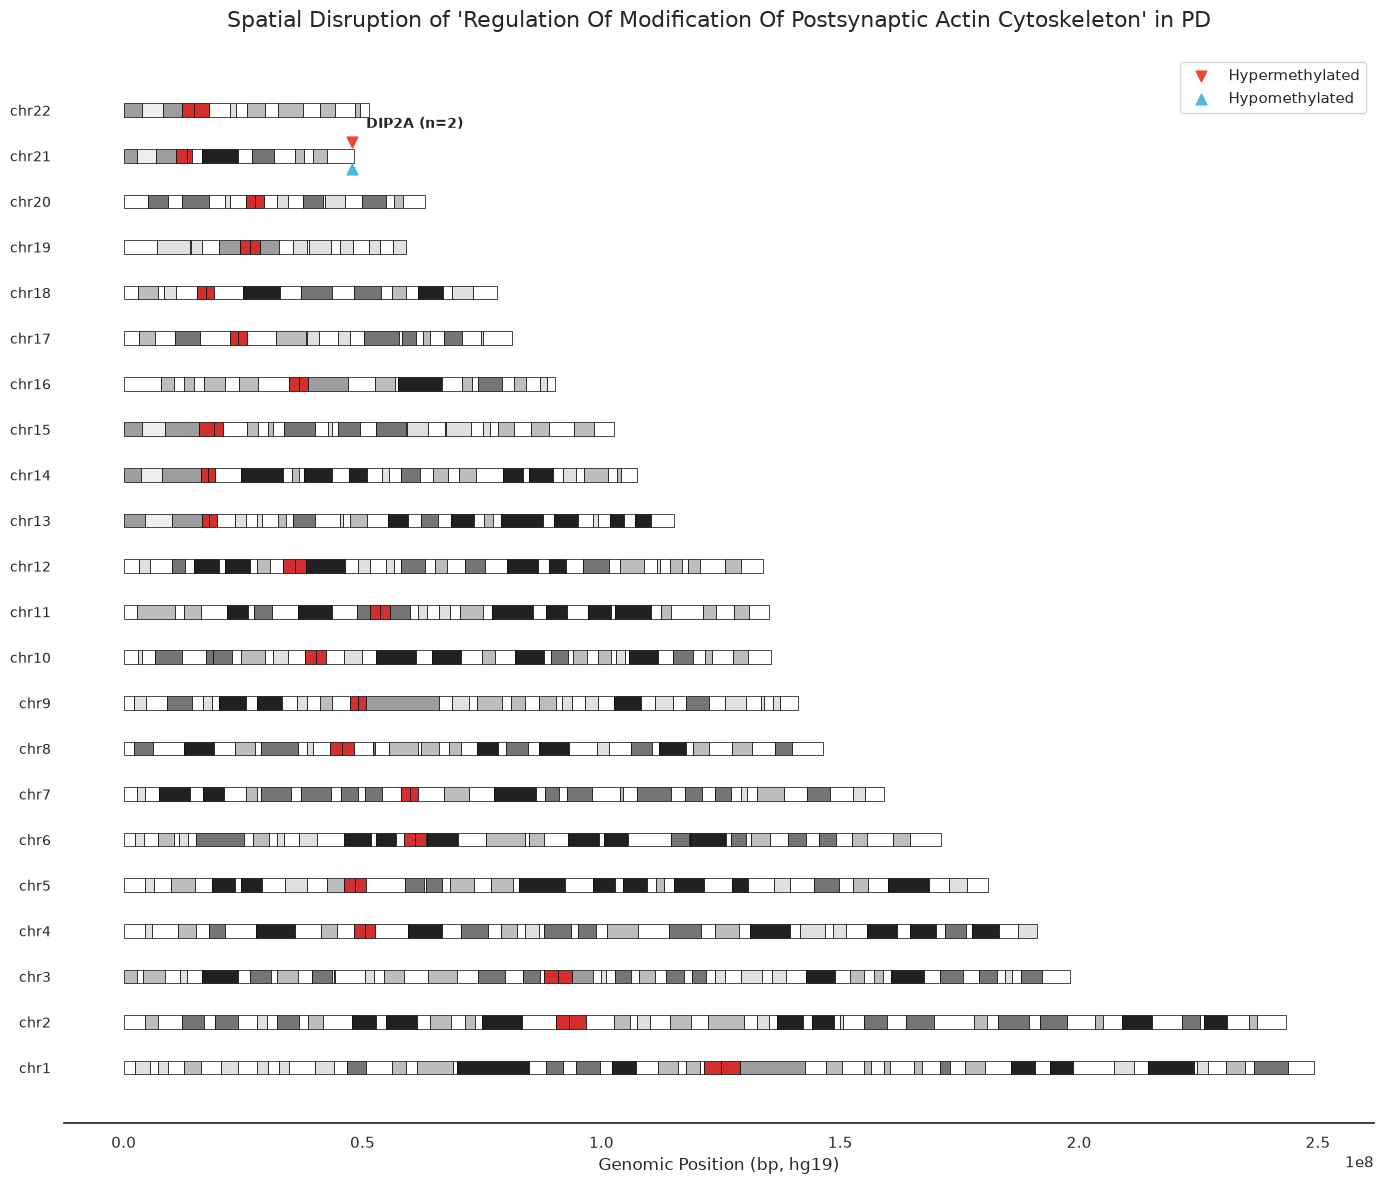

  Chromosome Target_Genes  CpG_Count  Mean_Delta_Beta  SD_Delta_Beta  \
0         21        DIP2A          2         0.000782       0.001195   

   Nominal_P    FDR_Q  
0    0.71897  0.71897  


In [59]:
target_pathway = "Regulation Of Modification Of Postsynaptic Actin Cytoskeleton (GO:1905274) BP"
pathway_stats_df = analyze_and_plot_pathway(
    target_term=target_pathway, 
    master_df=clinical_master_df, 
    manifest_df=manifest_df, 
    pheno_df=pheno_df, 
    m_matrix_df=m_matrix_df,
    output_pdf="/workspace/results/postsynaptic_actin_ideogram.pdf"
)
print(pathway_stats_df)

## Extraction of important features and pathway enrichment analysis

**The intersection between the GAT attention scores and the statistically significant Δβ values yields the set of genes that will passed down for pathway analysis**

The first attempt sets the minimum effect size (Δβ) for filtering to 5% and an FDR of < 0.05.  
Yet, using both of these threshold values yields no significant CpGs to assess further.  
After setting the effect size threshold to 0.01 and keeping the FDR at < 0.05 there were still no results.

In [2]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests
import gseapy as gp
import matplotlib.pyplot as plt

def extract_gold_standard_network(drivers_csv, m_matrix_df, pheno_df, manifest_df, 
                                  top_gat_pool=5000, 
                                  min_delta_beta=0.05, 
                                  max_fdr=0.05):
    """
    Finds the intersection of high GAT attention and significant clinical fold-change.
    """
    print(f"Loading top {top_gat_pool} GAT-selected drivers...")
    drivers_df = pd.read_csv(drivers_csv).sort_values('Attention_Score', ascending=False).head(top_gat_pool)
    target_cpgs = drivers_df['IlmnID'].tolist()
    
    # 1. Calculate Differential Methylation for the GAT Pool
    print("Calculating clinical effect sizes and p-values...")
    sub_matrix = m_matrix_df[target_cpgs]
    pd_indices = pheno_df.index[pheno_df['Sample_Group'] == 'PD'].tolist()
    ctrl_indices = pheno_df.index[pheno_df['Sample_Group'] == 'Control'].tolist()
    
    records = []
    for cpg in target_cpgs:
        pd_vals = sub_matrix.loc[pd_indices, cpg]
        ctrl_vals = sub_matrix.loc[ctrl_indices, cpg]
        
        # Means & Beta conversion
        mean_m_pd = pd_vals.mean()
        mean_m_ctrl = ctrl_vals.mean()
        mean_beta_pd = (2 ** mean_m_pd) / ((2 ** mean_m_pd) + 1)
        mean_beta_ctrl = (2 ** mean_m_ctrl) / ((2 ** mean_m_ctrl) + 1)
        delta_beta = mean_beta_pd - mean_beta_ctrl
        
        # Statistical Significance (Welch's t-test)
        stat, p_val = ttest_ind(pd_vals, ctrl_vals, equal_var=False)
        
        records.append({
            'IlmnID': cpg,
            'Delta_Beta': delta_beta,
            'Abs_Delta_Beta': abs(delta_beta),
            'P_Value': p_val,
            'Direction': 'Hypermethylated' if delta_beta > 0 else 'Hypomethylated'
        })
        
    stats_df = pd.DataFrame(records)
    
    # Apply FDR Correction
    _, stats_df['FDR_Q'] = multipletests(stats_df['P_Value'], method='fdr_bh')[:2]
    
    # Merge with GAT Attention and Manifest Annotations
    merged_df = pd.merge(stats_df, drivers_df[['IlmnID', 'Attention_Score']], on='IlmnID')
    merged_df = pd.merge(merged_df, manifest_df[['IlmnID', 'CHR', 'MAPINFO', 'UCSC_RefGene_Name']], on='IlmnID')
    
    # ==========================================
    # 2. The Crucible: Apply Strict Biological Filters
    # ==========================================
    print(f"Applying filters: FDR < {max_fdr} & |Delta Beta| >= {min_delta_beta}...")
    robust_df = merged_df[
        (merged_df['FDR_Q'] < max_fdr) & 
        (merged_df['Abs_Delta_Beta'] >= min_delta_beta)
    ].copy()
    
    print(f"-> {len(robust_df)} robust CpGs survived out of {top_gat_pool}.")
    
    # Extract unique genes from the surviving robust probes
    robust_genes = []
    for gene_string in robust_df['UCSC_RefGene_Name'].dropna():
        genes = str(gene_string).split(';')
        robust_genes.extend(genes)
        
    unique_robust_genes = list(set([g for g in robust_genes if g.lower() != 'nan']))
    print(f"-> Yielding {len(unique_robust_genes)} gold-standard genes for pathway analysis.\\n")
    
    robust_df.to_csv("/workspace/results/sgpd/gold_standard_pd_cpgs.csv", index=False)
    
    return unique_robust_genes, robust_df

def run_robust_gsea(gene_list):
    if len(gene_list) < 2:
        print("Not enough genes survived to run meaningful GSEA.")
        return None
        
    databases = [    
    'GO_Biological_Process_2026', 
    'Reactome_2022', 
    'KEGG_2021_Human',
    'Reactome_Pathways_2024',
    'GO_Molecular_Function_2026',
    'TRRUST_Transcription_Factors_2019',
    'TRANSFAC_and_JASPAR_PWMs',
    'ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X',
    'WikiPathways_2024_Human',
    'SynGO_2024',
    'WikiPathways_2024_Human',
    'Elsevier_Pathway_Collection'
]
    print(f"Running GSEA on {len(gene_list)} genes...")
    
    enrichment = gp.enrichr(gene_list=gene_list, gene_sets=databases, organism='human', outdir=None)
    results_df = enrichment.results
    
    fdr_sig = results_df[results_df['Adjusted P-value'] < 0.05]
    print(f"Found {len(fdr_sig)} strictly significant pathways!")
    
    if len(fdr_sig) > 0:
        #
        # 1. Filter out murine experiments from the results dataframe
        human_results_df = results_df[~results_df['Term'].str.contains('mouse', case=False, na=False)].copy()

        # 2. Re-plot the sanitized human-only results
        fdr_sig_human = human_results_df[human_results_df['Adjusted P-value'] < 0.05]

        if len(fdr_sig_human) > 0:
            # Use the filtered dataframe to build the plot
            gp.barplot(
                human_results_df, 
                column="Adjusted P-value", 
                title="Gold-Standard PD EWAS Enrichment (Human)",
                top_term=15, 
                figsize=(8, 6),
                ofname="/workspace/results/peg1/peg1_gsea_gold_standard_enrichment.png"
            )
            plt.show()
            #         
    else:
        print(results_df.head(10)[['Gene_set', 'Term', 'P-value', 'Adjusted P-value', 'Overlap']])
        
    return results_df


In [4]:
pheno_path = "/workspace/data/peg1/GSE111629_pheno_data.parquet"
m_matrix_path = "/workspace/data/peg1/GSE111629_m_matrix_full_reduced.parquet"

pheno_df = pd.read_parquet(pheno_path)
m_matrix_df = pd.read_parquet(m_matrix_path)

m_matrix_df.set_index("Sample_Name", inplace=True)

manifest_path = "/workspace/data/infinium450k_manifest.parquet"
manifest_df = pd.read_parquet(manifest_path)


In [15]:
pheno_df.set_index("Sample_Name", inplace=True)

In [16]:
robust_genes, robust_cpg_df = extract_gold_standard_network(
    drivers_csv="/workspace/results/peg1/pd_ensemble_epigenetic_drivers.csv",
    m_matrix_df=m_matrix_df,
    pheno_df=pheno_df,
    manifest_df=manifest_df,
    top_gat_pool=5000,
    min_delta_beta=0.01,
    max_fdr=0.05
)
robust_pathways = run_robust_gsea(robust_genes)

Loading top 5000 GAT-selected drivers...
Calculating clinical effect sizes and p-values...
Applying filters: FDR < 0.05 & |Delta Beta| >= 0.01...
-> 0 robust CpGs survived out of 5000.
-> Yielding 0 gold-standard genes for pathway analysis.\n
Not enough genes survived to run meaningful GSEA.


**Alternative: Blood, as a proxy tissue, is a difficult source to gain significant and hi-magnitude methylation effect sizes from. Hence a more relaxed set of thresholds is applied**

Here, the top 10,000 CpG's from GAT are tried for intersection with Δβ values of 1.5% whereby significance is set to a nominal p-value of 0.05 instead of the FDR.

In [17]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind
import gseapy as gp
import matplotlib.pyplot as plt

def extract_blood_optimized_network(drivers_csv, m_matrix_df, pheno_df, manifest_df, 
                                    top_gat_pool=10000, 
                                    min_delta_beta=0.015, # 1.5% shift (realistic for blood)
                                    max_nominal_p=0.05):  # Trusting GAT to handle the FDR burden
    
    drivers_df = pd.read_csv(drivers_csv).sort_values('Attention_Score', ascending=False).head(top_gat_pool)
    target_cpgs = drivers_df['IlmnID'].tolist()
    
    sub_matrix = m_matrix_df[target_cpgs]
    pd_indices = pheno_df.index[pheno_df['Sample_Group'] == 'PD'].tolist()
    ctrl_indices = pheno_df.index[pheno_df['Sample_Group'] == 'Control'].tolist()
    
    records = []
    for cpg in target_cpgs:
        pd_vals = sub_matrix.loc[pd_indices, cpg]
        ctrl_vals = sub_matrix.loc[ctrl_indices, cpg]
        
        mean_m_pd = pd_vals.mean()
        mean_m_ctrl = ctrl_vals.mean()
        mean_beta_pd = (2 ** mean_m_pd) / ((2 ** mean_m_pd) + 1)
        mean_beta_ctrl = (2 ** mean_m_ctrl) / ((2 ** mean_m_ctrl) + 1)
        delta_beta = mean_beta_pd - mean_beta_ctrl
        
        stat, p_val = ttest_ind(pd_vals, ctrl_vals, equal_var=False)
        
        records.append({
            'IlmnID': cpg,
            'Delta_Beta': delta_beta,
            'Abs_Delta_Beta': abs(delta_beta),
            'Nominal_P': p_val,
            'Direction': 'Hypermethylated' if delta_beta > 0 else 'Hypomethylated'
        })
        
    stats_df = pd.DataFrame(records)
    merged_df = pd.merge(stats_df, drivers_df[['IlmnID', 'Attention_Score']], on='IlmnID')
    merged_df = pd.merge(merged_df, manifest_df[['IlmnID', 'CHR', 'MAPINFO', 'UCSC_RefGene_Name']], on='IlmnID')
    
    # Apply blood-optimized filters
    robust_df = merged_df[
        (merged_df['Nominal_P'] < max_nominal_p) & 
        (merged_df['Abs_Delta_Beta'] >= min_delta_beta)
    ].copy()
    
    print(f"-> {len(robust_df)} blood-optimized CpGs survived.")
    
    robust_genes = []
    for gene_string in robust_df['UCSC_RefGene_Name'].dropna():
        genes = str(gene_string).split(';')
        robust_genes.extend(genes)
        
    unique_robust_genes = list(set([g for g in robust_genes if g.lower() != 'nan']))
    print(f"-> Yielding {len(unique_robust_genes)} genes for pathway analysis.\n")
    
    return unique_robust_genes, robust_df

# Execute extraction
# optimized_genes, optimized_cpg_df = extract_blood_optimized_network(...)
# Then pass optimized_genes to your run_robust_gsea() function

In [18]:
optimized_genes, optimized_cpg_df = extract_blood_optimized_network(drivers_csv="/workspace/results/peg1/pd_ensemble_epigenetic_drivers.csv",
                                                                    m_matrix_df=m_matrix_df,
                                                                    pheno_df=pheno_df,
                                                                    manifest_df=manifest_df)

-> 41 blood-optimized CpGs survived.
-> Yielding 23 genes for pathway analysis.



In [20]:
results_df = run_robust_gsea(optimized_genes)

Running GSEA on 23 genes...
Found 52 strictly significant pathways!


In [21]:
results_df.to_csv("/workspace/results/peg1/peg1_gsea_gold_standard_results_fdr.csv", index=False)